## Channel Modelling
This ChModel class provides a set of methods to model and analyze various transmission line characteristics and components.

Summary of Methods
   - rlgc: Computes the S-parameter matrix for a transmission line given the R, L, G, and C parameters, length, and frequency array.
   - impedance: Computes the S-parameter matrix for a 2-port network with a given impedance, which can be frequency-dependent.
   - admittance: Computes the S-parameter matrix for a 2-port network with a given shunt admittance, which can be frequency-dependent.
   - shunt_cap: Computes the S-parameter matrix for a 2-port network with a shunt capacitance specified at complex frequencies.
   - series_cap: Computes the S-parameter matrix for a 2-port network with a series capacitance specified at complex frequencies.
   - series: Combines multiple 2-port networks in series to get the overall ABCD parameters.
   - freq2impulse: Converts a frequency response to its corresponding impulse response, assuming a linearly spaced frequency array.
   - sparam: Computes the ABCD matrix for a 2-port network given its S-parameters, characteristic impedance, and frequency array.
   - zero_pad: Pads a discrete-time transfer function with zeros to meet a desired timestep in the time domain, extending the frequency vector accordingly.

In [19]:
import numpy as np

class ChModel:

    @staticmethod
    def rlgc(r, l, g, c, d, f):
        """
        Computes the S-parameter matrix for a transmission line at different frequencies.
        
        Parameters
        ----------
        r : float or array
            Resistance per unit length [Ω/m].
        l : float or array
            Inductance per unit length [H/m].
        g : float or array
            Conductance per unit length [S/m].
        c : float or array
            Capacitance per unit length [F/m].
        d : float
            Length of the transmission line [m].
        f : array
            Array of frequencies [Hz].
        
        Returns
        -------
        s : array
            S-parameter matrix of size (l, 2, 2) where s[n] is the 2x2 parameter matrix at frequency f[n].
        """
        w = 2 * np.pi * f # Angular frequencies, calculated as 𝑤=2𝜋𝑓.
        # Propagation constant multiplied by the length, which determines how signals decay and phase-shift
        # along the transmission line.
        gammad = d * np.sqrt((r + 1j * w * l) * (g + 1j * w * c))
        z0 = np.sqrt((r + 1j * w * l) / (g + 1j * w * c))
        A = np.cosh(gammad)
        B = z0 * np.sinh(gammad)
        C = np.sinh(gammad) / z0
        D = A
        
        s = np.zeros((f.size, 2, 2), dtype=np.complex128)
        s[:, 0, 0] = A
        s[:, 0, 1] = B
        s[:, 1, 0] = C
        s[:, 1, 1] = D
        
        return s

    @staticmethod
    def impedance(z):
        """
        Computes the S-parameter matrix for a 2-port network with impedance.

        Impedance, in electrical engineering, is the measure of opposition
        that a circuit presents to the flow of alternating current (AC).
        It extends the concept of resistance to AC circuits, accounting
        for both resistance 𝑅 and reactance 𝑋. Impedance is represented
        as a complex number: 
          𝑍=𝑅+𝑗𝑋 
        Where:
           𝑍 is the impedance (measured in ohms,Ω).
           𝑅 is the resistance (real part).
           𝑋 is the reactance (imaginary part).
           𝑗 is the imaginary unit (𝑗2=−1).
        Reactance comes from two components:
        Inductive Reactance (𝑋𝐿=2𝜋𝑓𝐿): Opposition due to inductors, 
          increasing with frequency.
        Capacitive Reactance (𝑋𝐶=1/2𝜋𝑓𝐶): Opposition due to capacitors,
          decreasing with frequency.

        Together, resistance and reactance determine how current and voltage
          interact in an AC system, including phase differences.
        
        Parameters
        ----------
        z : array
            Impedance values, possibly frequency-dependent.
        
        Returns
        -------
        s : array
            S-parameter matrix of size (l, 2, 2) where s[n] is the 2x2 parameter matrix at frequency f[n].
        """
        l = z.size
        s = np.zeros((l, 2, 2), dtype=np.complex128)
        s[:, 0, 0] = 1
        s[:, 0, 1] = z
        s[:, 1, 0] = 0
        s[:, 1, 1] = 1
        return s

    @staticmethod
    def admittance(y):
        """
        Computes the S-parameter matrix for a 2-port network with shunt admittance.

        Admittance is the measure of how easily a circuit allows the flow of alternating
        current (AC). It is the reciprocal of impedance and is represented as a complex number:
          𝑌=𝐺+𝑗𝐵
          Where:
           𝑌 is the admittance (measured in siemens, 𝑆).
           𝐺 is the conductance (real part), representing the ease of energy flow.
           𝐵 is the susceptance (imaginary part), indicating how reactive elements
             (inductors and capacitors) respond to AC.
        Admittance is related to impedance (𝑍) as follows:
          𝑌=1/𝑍
        For frequency-dependent components:
          Conductance (𝐺) corresponds to the reciprocal of resistance (𝑅).
          Susceptance (𝐵) is the reciprocal of reactance (𝑋).
        
        Parameters
        ----------
        y : array
            Admittance values, possibly frequency-dependent.
        
        Returns
        -------
        s : array
            S-parameter matrix of size (l, 2, 2) where s[n] is the 2x2 parameter matrix at frequency f[n].
        """
        l = y.size
        s = np.zeros((l, 2, 2), dtype=np.complex128)
        s[:, 0, 0] = 1
        s[:, 0, 1] = 0
        s[:, 1, 0] = y
        s[:, 1, 1] = 1
        return s

    @staticmethod
    def shunt_cap(c, w):
        """
        Computes the S-parameter matrix for a 2-port network with shunt capacitance.
        
        Parameters
        ----------
        c : float
            Shunt capacitance value [F].
        w : array
            Complex frequencies [rad/s].
        
        Returns
        -------
        s : array
            S-parameter matrix of size (l, 2, 2) where s[n] is the 2x2 parameter matrix at frequency f[n].
        """
        l = w.size
        s = np.zeros((l, 2, 2), dtype=np.complex128)
        s[:, 0, 0] = 1
        s[:, 0, 1] = 0
        s[:, 1, 0] = c * w
        s[:, 1, 1] = 1
        return s

    @staticmethod
    def series_cap(c, w):
        """
        Computes the S-parameter matrix for a 2-port network with series capacitance.
        
        Parameters
        ----------
        c : float
            Series capacitance value [F].
        w : array
            Complex frequencies [rad/s].
        
        Returns
        -------
        s : array
            S-parameter matrix of size (l, 2, 2) where s[n] is the 2x2 parameter matrix at frequency f[n].
        """
        l = w.size
        s = np.zeros((l, 2, 2), dtype=np.complex128)
        s[:, 0, 0] = 1
        s[:, 0, 1] = 1 / (c * w)
        s[:, 1, 0] = 0
        s[:, 1, 1] = 1
        return s

    @staticmethod
    def series(networks):
        """
        Series combination of 2-port networks.
        
        Parameters
        ----------
        networks : array
            Array containing the A, B, C, D matrix parameters of networks to be combined in series.
        
        Returns
        -------
        out : array
            Combined ABCD matrix parameters.
        """
        # np.matmul computes the dot product for 2D arrays (i.e., standard matrix multiplication).
        out = np.matmul(networks[0], networks[1])
        for i in range(2, networks.shape[0]):
            out = np.matmul(out, networks[i])
        return out

    @staticmethod
    def freq2impulse(H, f):
        """
        Returns the impulse response for a system with complex frequency response.
        
        Parameters
        ----------
        H : array
            Complex frequency response.
        f : array
            Frequency vector (must be linearly spaced).
        
        Returns
        -------
        h : array
            Impulse response.
        t : array
            Time vector.
        """
        # Components:
        #  H: Likely an array representing the frequency components of a signal (or a filter).
        # np.flip(H[1:-1]):
        #  Extracts all elements of H except the first and last ones (H[1:-1]).
        #  Reverses the order of these elements along the specified axis using np.flip.
        # np.conj(...):
        #  Takes the complex conjugate of the flipped array. This is often done to ensure
        #  conjugate symmetry, which is necessary for generating a real-valued signal after
        #  an inverse Fourier transform (IFFT).
        # np.concatenate(...): Combines the original array H with the conjugate-flipped portion
        #  to create a new array. This ensures that the resulting array Hd has the desired symmetry.
        # Purpose: This operation is commonly used to:
        #   Enforce Hermitian symmetry in the frequency domain, which is required for the
        #     time-domain signal to be real-valued after applying the IFFT.
        #   Construct symmetric signals, such as those encountered in digital filters or
        #     modulation schemes.
        Hd = np.concatenate((H, np.conj(np.flip(H[1:-1]))))

        # np.fft.ifft(Hd): Computes the IFFT of Hd, which transforms the frequency-domain data (Hd)
        #   back into the time domain.
        #   The output of ifft is generally complex because it handles signals with imaginary components.
        # np.real(...): Extracts the real part of the time-domain signal. This is often done because,
        #  in many practical cases (e.g., signal processing), the imaginary part represents numerical noise and can be discarded.
        h = np.real(np.fft.ifft(Hd))

        # np.linspace(start, stop, num): This function generates num evenly spaced values between start and stop (inclusive of both).
        #   Parameters:
        #     start = 0: The sequence starts from 0.
        #     stop = 1 / f[1]: The sequence ends at the reciprocal of the frequency value f[1].
        #       This likely represents the time period corresponding to the second frequency in array f.
        #     num = h.size + 1: The total number of points generated is one more than the size of h.
        #     [:-1]: Slices the generated array to exclude the last value. This ensures the resulting
        #            array t has exactly h.size elements, which is often useful to align the time points with the signal h.
        t = np.linspace(0, 1 / f[1], h.size + 1)[:-1]

        return h, t

    @staticmethod
    def sparam(s11, s12, s21, s22, z0, f):
        """
        ABCD matrix description of a 2-port network with S-parameters.
        
        Parameters
        ----------
        s11, s12, s21, s22 : array
            S-parameters.
        z0 : float
            Characteristic impedance.
        f : array
            Frequency array.
        
        Returns
        -------
        s : array
            ABCD matrix parameters at the frequencies in f.
        """
        s = np.zeros((f.size, 2, 2), dtype=np.complex_)
        s[:, 0, 0] = (1 + s11 - s22 - (s11 * s22 - s12 * s21)) / (2 * s21)
        s[:, 0, 1] = (z0 * (1 + s11 + s22 + (s11 * s22 - s12 * s21))) / (2 * s21)
        s[:, 1, 0] = (1 - s11 - s22 + (s11 * s22 - s12 * s21)) / (2 * z0 * s21)
        s[:, 1, 1] = (1 - s11 + s22 - (s11 * s22 - s12 * s21)) / (2 * s21)
        return s

    @staticmethod
    def zero_pad(H, f, t_d):
        """
        Pads discrete-time transfer function with zeros to meet desired timestep.
        
        Parameters
        ----------
        H : array
            Discrete-time transfer function.
        f : array
            Frequency vector.
        t_d : float
            Desired timestep.
        
        Returns
        -------
        H_zero_pad : array
            Zero-padded transfer function.
        f_zero_pad : array
            Extended frequency vector.
        h_0 : array
            Impulse response of zero-padded transfer function.
        t_0 : array
            Time vector corresponding to h_0.
        """
        f_step = f[1]
        f_max = f[-1]
        f_max_d = int(1 / (2 * t_d))

        # This line of code extends the frequency vector f by appending additional frequency
        # values to it, ensuring the desired frequency range is covered. Here's a step-by-step explanation:
        # Components:
        #   np.hstack((...)):
        #     Stacks arrays horizontally (along the last axis).
        #     In this case, it concatenates the original f array and a newly generated array of additional frequency values.
        #   np.linspace(f_max, f_max_d, int((f_max_d - f_max) / f_step)):
        #     Generates a linearly spaced array of additional frequencies starting from f_max
        #      (the last frequency in f) to f_max_d (the maximum desired frequency, calculated earlier based on the timestep).
        #     The int((f_max_d - f_max) / f_step) determines the number of points, ensuring the spacing between
        #      the frequencies matches the original f_step.
        f_zero_pad = np.hstack((f, np.linspace(f_max, f_max_d, int((f_max_d - f_max) / f_step))))
        H_zero_pad = np.hstack((H, np.zeros((f_zero_pad.size - H.size))))
        h_0, t_0 = ChModel.freq2impulse(H_zero_pad, f_zero_pad)
        return H_zero_pad, f_zero_pad, h_0, t_0


## Example Usage
Here is an example of how to use the ChModel class to compute S-parameters and impulse responses:

In [20]:
import numpy as np

# Example parameters
r = 0.02  # Resistance per unit length [Ω/m]
l = 2e-7  # Inductance per unit length [H/m]
g = 1e-9  # Conductance per unit length [S/m]
c = 1e-12  # Capacitance per unit length [F/m]
d = 100    # Length of the transmission line [m]
f = np.array([1e6, 10e6, 100e6])  # Frequency array [Hz]

# Compute S-parameters for the transmission line
s_params = ChModel.rlgc(r, l, g, c, d, f)
print("S-parameters for the transmission line:")
print(s_params)

# Impedance example
z = np.array([50, 75, 100])  # Impedance values [Ω]
impedance_s_params = ChModel.impedance(z)
print("S-parameters for the impedance network:")
print(impedance_s_params)

# Shunt capacitance example
c_shunt = 1e-12  # Capacitance [F]
w = 2 * np.pi * f  # Angular frequency [rad/s]
shunt_cap_s_params = ChModel.shunt_cap(c_shunt, w)
print("S-parameters for the shunt capacitance network:")
print(shunt_cap_s_params)

# Zero padding example
H = np.array([0.1, 0.2, 0.3, 0.4])  # Example transfer function
f_example = np.array([0.1, 0.2, 0.3, 0.4])  # Example frequency vector
t_d = 0.001  # Desired timestep [s]
H_zero_pad, f_zero_pad, h_0, t_0 = ChModel.zero_pad(H, f_example, t_d)
print("Zero-padded transfer function:")
print(H_zero_pad)
print("Extended frequency vector:")
print(f_zero_pad)
print("Impulse response:")
print(h_0)
print("Time vector:")
print(t_0)

S-parameters for the transmission line:
[[[ 9.60780689e-01+6.26283617e-04j  1.94741196e+00+1.24016976e+02j]
  [-3.31749692e-08+6.20082804e-04j  9.60780689e-01+6.26283617e-04j]]

 [[-9.45503623e-01+7.35386729e-04j -8.40234053e-01+1.45622227e+02j]
  [-5.34839343e-06+7.28102687e-04j -9.45503623e-01+7.35386729e-04j]]

 [[-9.84716012e-01+3.93377648e-04j -9.88424647e-01+7.78967752e+01j]
  [-5.00349151e-06+3.89483087e-04j -9.84716012e-01+3.93377648e-04j]]]
S-parameters for the impedance network:
[[[  1.+0.j  50.+0.j]
  [  0.+0.j   1.+0.j]]

 [[  1.+0.j  75.+0.j]
  [  0.+0.j   1.+0.j]]

 [[  1.+0.j 100.+0.j]
  [  0.+0.j   1.+0.j]]]
S-parameters for the shunt capacitance network:
[[[1.00000000e+00+0.j 0.00000000e+00+0.j]
  [6.28318531e-06+0.j 1.00000000e+00+0.j]]

 [[1.00000000e+00+0.j 0.00000000e+00+0.j]
  [6.28318531e-05+0.j 1.00000000e+00+0.j]]

 [[1.00000000e+00+0.j 0.00000000e+00+0.j]
  [6.28318531e-04+0.j 1.00000000e+00+0.j]]]
Zero-padded transfer function:
[0.1 0.2 0.3 ... 0.  0.  0. ]
E

## Differential transfer function for a 4-port network
This function four_port_to_diff2 calculates the differential transfer function for a 4-port network and can also return the corresponding frequency vector, impulse response, and time vector. It uses the given S-parameters of the network, along with source and load impedance, to compute the transfer function. The function handles differential mode conversion and can normalize the transfer function or compute the impulse response with optional zero-padding.

It's a robust way to analyze the differential behavior of a 4-port network.

In [21]:
def four_port_to_diff(network, port_def, source, load, option = 0, t_d = None):
    """
    The four_port_to_diff function calculates the differential transfer function
    for a 4-port network defined by given S-parameters. It can also return the
    corresponding frequency vector, impulse response, and time vector.

    Parameters
    ----------
    network : skrf Network
        4 port network object
        example: 
            s4p_file = 'path/to/touchstonefile.s4p'
            network = rf.Network(s4p_file)
    
    port_def: 2*2 array
        defines TX and RX side ports of network
        example:
            port_def = np.array([[TX1_index, RX1_index],[TX2_index, RX2_index]])
            
            PORT DEFINITIONS: 
                Port   1  ----->  TX Side      G11     RX Side  <-----  Port   2
                Port   3  ----->  TX Side      G12     RX Side  <-----  Port   4
                
            port_def = np.array([[0, 1],[2, 3]])

    Returns
    -------
    H : array
        tranfer function of differential channel
    
    f : array
        frequency vector
        
    h : array
        impulse response
    
    t = array
        time vector
        
    """
    # Extract S-parameters and Frequency
    s_params = network.s
    f = network.f
    pts = f.size

    #change port def
    #ports = np.array([1,3,2,4])
    s_params_new = np.copy(s_params)
    
    s_params_new[:,1,:] = np.copy(s_params[:,2,:])
    s_params_new[:,2,:] = np.copy(s_params[:,1,:])
    
    s_params_new[:,:,1] = np.copy(s_params[:,:,2])
    s_params_new[:,:,2] = np.copy(s_params[:,:,1])
    
    s_params_new[:,1,2] = np.copy(s_params[:,1,2])
    s_params_new[:,2,1] = np.copy(s_params[:,2,1])
    
    s_params_new[:,1,1] = np.copy(s_params[:,2,2])
    s_params_new[:,2,2] = np.copy(s_params[:,1,1])

    # Define Mode Conversion Matrix
    # [[ 1 -1  0  0]
    #  [ 0  0  1 -1]
    #  [ 1  1  0  0]
    #  [ 0  0  1  1]]
    M = np.array([[1,-1,0,0],[0,0,1,-1],[1,1,0,0],[0,0,1,1]])
    # [[ 1  0  1  0]
    #  [-1  0  1  0]
    #  [ 0  1  0  1]
    #  [ 0 -1  0  1]]
    invM = np.transpose(M)
    
    # Compute Mixed Mode S-parameters
    smm_params = np.zeros((4,4,pts), dtype = complex)
    
    for i in range(pts):
        # Left-hand Side:
        #   smm_params[:, :, i]: This extracts the i-th slice from the 3D array
        #    smm_params, which has dimensions (x, y, z) where i represents the index along the third dimension (z).
        # Right-hand Side:
        #   (M @ s_params_new[i, :, :] @ invM): This is a matrix multiplication operation involving three matrices:
        #     M: A matrix (transformation matrix).
        #     s_params_new[i, :, :]: The i-th slice from the 3D array s_params_new. This represents a matrix corresponding to index i.
        #     invM: Another matrix, the transpose of M.
        #   The @ operator represents matrix multiplication in NumPy.
        #   The result of this is a matrix resulting from the chain multiplication 𝑀⋅𝑠(params)(𝑖)⋅invM
        # Division by 2: The entire result from the matrix multiplication is divided by 2. This scales 
        #   the resulting matrix element-wise.
        smm_params[:,:,i] = (M@s_params_new[i,:,:]@invM)/2
    
    diff_s_params = smm_params[0:2,0:2,:]
    
    # Calculate Reflection Coefficients
    zl = load*np.ones((1,1,pts))
    zs = source*np.ones((1,1,pts))
    z0 = network.z0[0,0]*np.ones((1,1,pts))

    #reflection coefficients
    gammaL = (zl - z0) / (zl + z0)
    gammaL[zl == np.inf] = 1 
    
    gammaS = (zs - z0) / (zs + z0)
    gammaS[zs == np.inf] = 1
    
    # Compute Transfer Function H
    gammaIn = (diff_s_params[0,0,:] + diff_s_params[0,1,:] * diff_s_params[1,0,:] * gammaL) / (1 - diff_s_params[1,1,:] * gammaL)
    
    H = diff_s_params[1,0,:] * (1 + gammaL) * (1 - gammaS) / (1 - diff_s_params[1,1,:] * gammaL) / (1 - gammaIn * gammaS) / 2
    
    # H.reshape(...):
    #  The reshape method in NumPy is used to change the shape of an array without changing its data.
    #  The new shape must be compatible with the original number of elements in H. That is, the product
    #  of the dimensions in the new shape (pts) must equal the total number of elements in H.
    # If H initially has 200 elements and pts = 100, the reshape operation effectively turns the
    # array into a 1D array with 100 elements.
    H = H.reshape(pts,)

    # Normalize Transfer Function if Option is Set
    if option == 1:
        H = H/H[0]
    
    # Compute Impulse Response
    if t_d != None:
        H, f, h, t = ChModel.zero_pad(H,f,t_d)
    else:
        h, t = ChModel.freq2impulse(H,f)
        
    return H, f, h, t

## Example
Here’s an example to illustrate how the four_port_to_diff2 function can be used. We'll assume that you have an skrf Network object representing a 4-port network.

In [22]:
import skrf as rf
import numpy as np

# Load the touchstone file to create a 4-port network
s4p_file = './examples/example_channel/mellitz_3ck_04_1119_CACR/Tp0_Tp5_28p5db_FQSFP_thru.s4p'
network = rf.Network(s4p_file)

# Define the port definitions
port_def = np.array([[0, 1], [2, 3]])

# Define source and load impedances (ohms)
source = 50
load = 50
'''
# Call the function and retrieve the results
H, f, h, t = four_port_to_diff(network, port_def, source, load, option=1, t_d=1e-9)

# Display the results
print("Transfer Function (H):", H)
print("Frequency Vector (f):", f)
print("Impulse Response (h):", h)
print("Time Vector (t):", t)
'''

'\n# Call the function and retrieve the results\nH, f, h, t = four_port_to_diff(network, port_def, source, load, option=1, t_d=1e-9)\n\n# Display the results\nprint("Transfer Function (H):", H)\nprint("Frequency Vector (f):", f)\nprint("Impulse Response (h):", h)\nprint("Time Vector (t):", t)\n'

## Signal
This Signal class provides several useful methods for dealing with PAM-4 and NRZ signals.

In [23]:
"""
This file contains miscellaneous functions for digital signal processing
"""

import numpy as np
import matplotlib.pyplot as plt

class Signal:
    @staticmethod    
    def grey_encode(x):
        """encodes 2 bits into one pam4 symbol with grey encoding
        grey_encode function is designed to encode a 2-bit binary array into a single
        PAM-4 symbol using Gray encoding. This approach helps minimize errors in digital communications.
        Gray Encoding: Minimizes the difference between consecutive symbols.
        It's particularly useful in communication systems to reduce the probability of error when symbols are close in value.
    
        Parameters
        ----------
        x : array
            contains the two bits to be encoded
        
        Returns
        -------
        int
            the pam4 symbol that represents x
    
        """
        if (x[0] == 0):
            if (x[1] == 0):
                return 0
            else:
                return 1
        else:
            if (x[1] == 0):
                return 3
            else:
                return 2
            
    @staticmethod    
    def grey_decode(symbol):
        """decodes one pam4 symbol into two bits with grey decoding
    
        Parameters
        ----------
        symbol : int
            the pam4 symbol
        
        Returns
        -------
        array
            the two bits that represent symbol
        """
        if symbol == 0 :
            return np.array([0,0],dtype = np.uint8)
        if symbol == 1 :
            return np.array([0,1],dtype = np.uint8)
        if symbol == 2 :
            return np.array([1,1],dtype = np.uint8)
        if symbol == 3 :
            return np.array([1,0],dtype = np.uint8)
    
    @staticmethod    
    def natural_encode(x):
        """encodes 2 bits into one pam4 symbol with natural encoding
    
        Parameters
        ----------
        x : array
            contains the two bits to be encoded
        
        Returns
        -------
        int 
            the pam4 symbol that represents x
    
        """
        
        if (x[0] == 0):
            if (x[1] == 0):
                return 0
            else:
                return 1
        else:
            if (x[1] == 0):
                return 2
            else:
                return 3
            
    @staticmethod    
    def natural_decode(symbol):
        """decodes one pam4 symbol into two bits with natural decoding
    
        Parameters
        ----------
        symbol : int
            the pam4 symbol
        
        Returns
        -------
        array
            the two bits that represent symbol
        """
        if symbol == 0 :
            return np.array([0,0],dtype = np.uint8)
        if symbol == 1 :
            return np.array([0,1],dtype = np.uint8)
        if symbol == 2 :
            return np.array([1,0],dtype = np.uint8)
        if symbol == 3 :
            return np.array([1,1],dtype = np.uint8)   
        
    @staticmethod    
    def pam4_decision(x,l,m,h):
        """produces pam4 symbol from analog voltage
        
        Parameters
        ----------
        x : float
            the analog voltage
        
        l: float
            voltage threshold between 0 and 1 symbol
        
        m: float
            voltage threshold between 1 and 2 symbol
            
        h: float
            voltage threshold between 2 and 3 symbol
        
        Returns
        -------
        int
            the pam4 symbol that represents x
        """
        if x<l:
            return 0
        elif x<m:
            return 1
        elif x<h:
            return 2
        else:
            return 3
    
    @staticmethod    
    def nrz_decision(x,t):
        """produces nrz symbol from analog voltage
        
        Parameters
        ----------
        x : float
            the analog voltage
        
        t: float
            voltage threshold between 0 and 1 symbol
        
        Returns
        -------
        int
            the nrz symbol that represents x
        """
        if x<t:
            return 0
        else:
            return 1
    
    
    @staticmethod    
    def pam4_input_BR(data_in, voltage_levels = np.array([-3, -1, 1, 3])):
        """produces baud-rate-sampled voltage waveform from quaternary sequence 
        
        Parameters
        ----------
        data_in : array
            quaternary sequence containing pam4 symbols
        
        voltage_levels: array
            voltage levels corresponding to each pam4 symbol
        
        Returns
        -------
        signal : array
            baud-rate-sampled voltage waveform corresponding to data_in
        """
    
        signal = np.zeros(data_in.size)
        
        for i in range(data_in.size):
            if (data_in[i]==0):
                signal[i] = voltage_levels[0]
            elif (data_in[i]==1):
                signal[i] = voltage_levels[1]
            elif (data_in[i]==2):
                signal[i] = voltage_levels[2]
            elif (data_in[i]==3):
                signal[i] = voltage_levels[3]
            else:
                print('unexpected symbol in data_in')
                return False
        
        return signal
    
    @staticmethod    
    def nrz_input_BR(data_in, voltage_levels = np.array([-1, 1])):
        """produces baud-rate-sampled voltage waveform from binary sequence 
        
        Parameters
        ----------
        data_in : array
            binary sequence
        
        voltage_levels: array
            voltage levels corresponding to 0 and 1 bits
        
        Returns
        -------
        signal : array
            baud-rate-sampled voltage waveform corresponding to data_in
        """
    
        signal = np.zeros(data_in.size)
        
        for i in range(data_in.size):
            if (data_in[i]==0):
                signal[i] = voltage_levels[0]
            elif (data_in[i]==1):
                signal[i] = voltage_levels[1]
            else:
                print('unexpected symbol in data_in')
                return False
        
        return signal
    
    @staticmethod    
    def nrz_a2d(signal, samples_per_symbol, threshold):
        """slices signal and compares to threshold to convert analog signal vector to binary sequence
            signal is sampled at indeicies that are multiples of samples_per_symbol
    
        Parameters
        ----------
        signal: array
            signal vector at RX
            
        samples_per_symbol: int
            number of timesteps per one bit
            
        threshold: float
            voltage threshold between 0 and 1 symbol
        
        Returns
        -------
        data : array
            binary sequence generated from signal
    
        """
        
        data = np.zeros(int(signal.size/samples_per_symbol), dtype = np.uint8)
        
        for i in range(data.size):
            data[i] = Signal.nrz_decision(signal[i*samples_per_symbol], threshold)
                
        return data
    
    @staticmethod    
    def pam4_a2d(signal, samples_per_symbol, l, m, h):
        """slices signal and compares to voltage_levelsto convert analog signal vector to binary sequence
            signal is sampled at indeicies that are multiples of samples_per_symbol
    
        Parameters
        ----------
        signal: array
            signal vector at RX
            
        samples_per_symbol: int
            number of samples per UI
            
        l: float
            voltage threshold between 0 and 1 symbol
        
        m: float
            voltage threshold between 1 and 2 symbol
            
        h: float
            voltage threshold between 2 and 3 symbol
        
        Returns
        -------
        data : array
            quaternary sequence generated from signal
    
        """
        
        data = np.zeros(int(signal.size/samples_per_symbol), dtype = np.uint8)
        
        for i in range(data.size):
            data[i] = Signal.pam4_decision(signal[i*samples_per_symbol],l,m,h)
                
        return data
    
    
    @staticmethod    
    def channel_coefficients(pulse_response, t, samples_per_symbol, n_precursors, n_postcursors, res=70, title = "Channel Coefficients"):
        #TODO: check for not long enough signal
        #make t optional arg
        """measures and plots channel coefficients from pulse response
    
        Parameters
        ----------
        pulse_response: array
        
        t: array
            time vector corresponding to pulse response
    
        samples_per_symbol: int
            number of samples per UI
            
        n_precursors : int
            number of UI before main cursor to measure
            
        n_postcursors : int
            number of UI before after cursor to measure
            
        res : int
            resolution of plot
            
        title: str
            title of plot
        
        Returns
        -------
        channel_coefficients : array
            channel coefficents measured from pulse response
    
        """
        #number of channel coefficients
        # n_cursors: Total number of channel coefficients.
        n_cursors = n_precursors + n_postcursors + 1
        # channel_coefficients: Initializes an array to store the channel coefficients.
        channel_coefficients = np.zeros(n_cursors)
        
        #for plotting
        t_vec = np.zeros(n_cursors)
        xcoords = []
        half_symbol = int(round(samples_per_symbol/2))
        
        #find peak of pulse response = main cursor sample time
        # np.amax(pulse_response):
        #   This function returns the maximum value within the array pulse_response.
        # np.where(pulse_response == np.amax(pulse_response)):
        #   np.where(condition) returns the indices of elements in the array that satisfy the given condition.
        #   In this case, it returns the indices of elements in pulse_response that are equal to the maximum value.
        # [0][0]:
        #   np.where returns a tuple of arrays, one for each dimension of the array. Since pulse_response is 1D,
        #   it returns a single array of indices in the first (and only) dimension.
        #   [0] accesses this array of indices.
        #   [0] (again) retrieves the first index in this array. This ensures that if there are multiple maximum
        #     values, only the first occurrence is captured.
        max_idx = np.where(pulse_response == np.amax(pulse_response))[0][0]
        
        # Loop: Iterates over each cursor to measure the pulse response.
        for cursor in range(n_cursors):
            
            #index of channel coefficint
            # a: Index offset from the main cursor.
            a = cursor - n_precursors
            
            #measure pulse response
            # channel_coefficients[cursor]: Measures the pulse response at the corresponding cursor position.
            channel_coefficients[cursor] = pulse_response[max_idx+a*samples_per_symbol]
            
            #for plotting
            xcoords = xcoords + [1e9*t[max_idx+a*samples_per_symbol-half_symbol]]
            t_vec[a+n_precursors] = t[max_idx + a*samples_per_symbol]
            
        xcoords = xcoords + [1e9*t[max_idx+(n_postcursors+1)*samples_per_symbol-half_symbol]]
        
        
        
        #plot pulse response and cursor samples
        plt.figure(dpi=res)
        plt.plot(t_vec*1e9, channel_coefficients, 'o',label = 'Cursor samples')
        plt.plot(t*1e9,pulse_response, label = 'Pulse Response')
        plt.xlabel("Time [ns]")
        plt.ylabel("[V]")
        
        ll = t[max_idx-samples_per_symbol*(n_precursors+2)]*1e9
        ul = t[max_idx+samples_per_symbol*(n_postcursors+2)]*1e9
        
        #print(ll,ul)
        plt.xlim([ll,ul])
        plt.title(title)
        plt.legend()
        
        #lines to seperate UI
        for xc in xcoords:
            plt.axvline(x=xc,color = 'grey',label ='UIs', linewidth = 0.25)
        plt.pause(1)

        
        return channel_coefficients
    
    @staticmethod    
    def forcing_ffe(n_taps_pre, channel_coefficients, target = None):
        """generates ffe tap coefficients that force pulse response to target (zero-forcing if target not specified)
        forcing_ffe function is designed to generate FFE tap coefficients that force the pulse response to a target
        (zero-forcing if the target is not specified).
    
        Parameters
        ----------
        n_taps_pre:
            number of channel coefficients before main_cursor
        
        channel_coefficients: array
            channel coeffients that will be affected by FFE
    
        target: array
            this specifies what the pulse response will be forced to be
            should have same length as channel_coefficients
        
        Returns
        -------
        ffe_tap_weights : array
            ffe tap weights that force channel_coefficients to target
    
        """
        
        #number of taps
        # Calculate Number of Taps
        n_taps = channel_coefficients.size
    
        # n_taps_post: Number of post-cursor taps.
        n_taps_post = n_taps - n_taps_pre -1
        
        #build matrix for zero-forcing
        A = np.zeros((n_taps,n_taps))
    
        # Loop: Fills the matrix A with the channel coefficients.
        for i in range(n_taps):
            A += np.diag(np.ones(n_taps-abs(i-n_taps_pre))*channel_coefficients[i],(n_taps_pre-i) )
    
    
        if target == None:
            #do zero-forcing
            # c: Defines the target vector. If target is not provided, a zero-forcing target is used.
            c = np.zeros((n_taps,1))
            c[n_taps_pre] = 1
        else:
            c = target
    
        #solve matrix inversion
        # b: Solves the linear system by matrix inversion to find the FFE tap weights.
        b = np.linalg.inv(A)@c
    
        #normalize ffe tap weights so main-cursor tap weight is 1
        b = b/np.sum(abs(b))
    
        ffe_tap_weights = b.T[0]
    
        ffe_tap_weights = ffe_tap_weights * 1/ffe_tap_weights[n_taps_pre]
        
        return ffe_tap_weights
    
    
    @staticmethod    
    def shift_signal(signal, samples_per_symbol):
        """Shifts signal vector so that 0th element is at centre of eye, heuristic
    
        shift_signal function aims to shift a signal vector so that the 0th
        element is at the center of the eye diagram, using a heuristic based
        on minimizing a loss function.
    
        Parameters
        ----------
        signal: array
            signal vector at RX
            
        samples_per_symbol: int
            number of samples per UI
        
        Returns
        -------
        array
            signal shifted so that 0th element is at centre of eye
    
        """
        
        #Loss function evaluated at each step from 0 to steps_per_signal
        # loss_vec: Initializes an array to store the loss function values evaluated at each step.
        loss_vec = np.zeros(samples_per_symbol)
        
        # Loop: Iterates over each possible starting point within one symbol period.
        for i in range(samples_per_symbol):
            
            # samples: Extracts samples at intervals of samples_per_symbol, starting from index i.
            samples = signal[i::samples_per_symbol]
            
            #add loss for samples that are close to threshold voltage
            # loss_vec[i]: Calculates the loss for each shift position by summing the squared magnitudes of the samples.
            loss_vec[i] += np.sum(abs(samples)**2)
            
        #find shift index with least loss
        # shift: Finds the index with the maximum loss value. The optimal shift index is where the loss is maximized
        # (this can be adjusted based on the desired heuristic).
        shift = np.where(loss_vec == np.max(loss_vec))[0][0]
        
       # plt.plot(np.linspace(0,samples_per_symbol-1,samples_per_symbol),loss_vec)
       # plt.show()
        
        return np.copy(signal[shift+1:])
    
    @staticmethod    
    def lms_equalizer(y, mu, N, w_ffe, FFE_pre, w_dfe, voltage_levels,
            alpha=None, reference=None, update_rate=1):
        """optimizes DFE and/or FFE weights for a particular signal, by using a
        Least-Mean Squares (LMS) objective function.
    
        lms_equalizer function is designed to optimize the Decision Feedback
        Equalizer (DFE) and/or Feed-Forward Equalizer (FFE) weights for a particular
        signal using the Least-Mean Squares (LMS) algorithm.
    
        Parameters
        ----------
        y: array
            signal to be equalized
        mu: number
            learning rate factor for the LMS update
        N: int
            length of `y` to be equalized
        w_ffe: array
            initial FFE weights, starting fromt the last pre-tap (oldest) to the
            last post-tap (future-most)
        FFE_pre: int
            number of pre-tap weights in FFE. The number of post-taps are implied
            based on len(w_ffe) and FFE_pre.
        w_dfe: array
            initial DFE weights, starting from the first pre-tap.
        voltage_levels: array
            discrete voltage levels to use in DFE optimization
        alpha: array (optional)
            used to fix the first `len(alpha)` weights in `w_dfe`, starting from the
            first pre-tap. these weights will not be optimized and will stay constant
            throughout LMS updates.
        reference: array (optional)
            if provided, LMS will attempt to optimize according to the error between
            the signal and reference, rather than estimating it based on the cloest
            voltage level. `len(reference)` may be less than `len(y)`, in which case
            only the first `len(reference)` updates will be optimized in this manner.
        update_rate: int (optional)
            LMS update will only be performed on each `update_rate`-th iteration.
            However, the equalized signal will still be computed on the skipped iterations.
    
        Returns
        -------
        w_ffe: array
            optimized FFE weights
        w_dfe: array
            optimized DFE weights
        v_ffe: array
            signal computed after FFE optimization
        v_dfe: array
            signal computed after FFE and DFE optimization
        z: array
            signal quantized from v_dfe
        e: array
            evaluated error used for LMS optimization
        """
        if w_ffe is None and w_dfe is None:
            print("warning: training nothing since both w_ffe and w_dfe were None")
    
        is_cooptimizing = w_ffe is not None and w_dfe is not None
        if (not is_cooptimizing) and (alpha is not None):
            print("warning: alpha is set but we're not co-optimizing")
    
        voltage_levels = voltage_levels.copy()
    
        if w_ffe is not None:
            w_ffe = np.array(w_ffe)
            FFE_taps = len(w_ffe)
            FFE_post = FFE_taps - FFE_pre - 1
        else:
            FFE_taps = 0
            FFE_post = 0
    
        if w_dfe is not None:
            w_dfe = np.array(w_dfe)
            DFE_taps = len(w_dfe)
        else:
            DFE_taps = 0
    
        e = np.zeros(N)
        v_dfe = np.zeros(N)
        v_ffe = np.zeros(N)
        z = np.zeros(N)
    
        # min_delay: The minimum delay to start processing symbols.
        min_delay = max(FFE_post, DFE_taps)
        # Loop: Iterates over the signal length.
        for k in range(min_delay, N - FFE_pre):
            # y_k: Segment of the input signal for FFE.
            y_k = y[k - FFE_post:k + FFE_pre + 1][::-1]
            # z_k: Segment of the quantized signal for DFE.
            z_k = z[k - DFE_taps:k][::-1]
    
            # alpha takes over the first len(alpha) terms of w_dfe
            # Weights Fixing: Optionally fixes the initial DFE weights based on alpha.
            if is_cooptimizing and alpha is not None:
                w_dfe[:len(alpha)] = alpha
    
            # FFE Output: Computes the FFE output.
            if w_ffe is not None:
                v_ffe[k] = np.dot(y_k, w_ffe)
            else:
                v_ffe[k] = y_k[0]
    
            # DFE Output: Computes the DFE output.
            if w_dfe is not None:
                v_dfe[k] = v_ffe[k] - np.dot(z_k, w_dfe)
            else:
                v_dfe[k] = v_ffe[k]
    
            # Quantization: Quantizes the DFE output.
            z[k] = Signal._quantize(v_dfe[k], voltage_levels)
            if reference is None or k >= len(reference):
                y_ref = z[k]
            else:
                y_ref = reference[k]
    
            # Error Calculation: Computes the error for LMS updates.
            e[k] = v_dfe[k] - y_ref
            # LMS Update: Updates the weights based on the error and learning rate.
            if (k - min_delay) % update_rate == 0:
                #print(k)
                if w_ffe is not None:
                    w_ffe -= mu * e[k] * y_k
                if w_dfe is not None:
                    w_dfe += mu * e[k] * z_k
    
        if is_cooptimizing and alpha is not None:
            w_dfe[:len(alpha)] = alpha
    
        end = N - FFE_pre
        return w_ffe, w_dfe,\
                v_ffe[min_delay:end],\
                v_dfe[min_delay:end],\
                z[min_delay:end],\
                e[min_delay:end]
    
    @staticmethod    
    def _quantize(signal, voltage_levels):
        '''
        _quantize function is designed to quantize a given signal to the nearest
        voltage level from a specified set of voltage levels. This function will
        be used within your LMS equalizer to quantize the signal after equalization.
        '''
        # np.abs(voltage_levels - signal): Computes the absolute difference between
        # each voltage level and the signal.
        # argmin(): Finds the index of the smallest difference, i.e., the index
        # of the voltage level closest to the signal.
        idx = np.abs(voltage_levels - signal).argmin()
        return voltage_levels[idx]
    
    

## Loading in Touchstone
This file shows example of loading in touchstone file for differential channel and generating bode plot and impulse response

To run this file:
    - download zipped touchstone files from : https://www.ieee802.org/3/ck/public/tools/cucable/mellitz_3ck_04_1119_CACR.zip
    - Place the file Tp0_Tp5_28p5db_FQSFP_thru.s4p in the working directory, with this file. It contains s-paramater measurements for 2m copper cable connector with 28dB insertion loss at 26.56Ghz from IEEE 802.df public channels
    - create a subdirectory called 'data' in the working directory. this is where data generated from this script will be saved for use in other examples


C:\Users\fkeyh\AppData\Local\Temp\ipykernel_9040\3237396042.py:38: RuntimeWarning: divide by zero encountered in log10
  plt.plot(1e-9*f,20*np.log10(abs(H_thru)), color = "blue", label = "THRU channel", linewidth = 0.8)


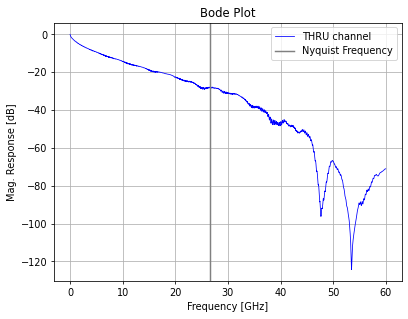

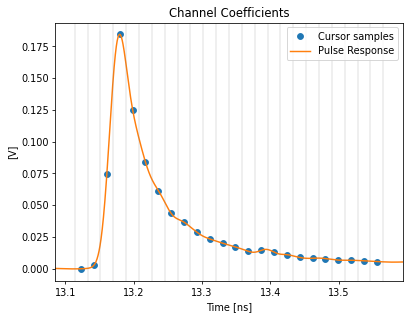

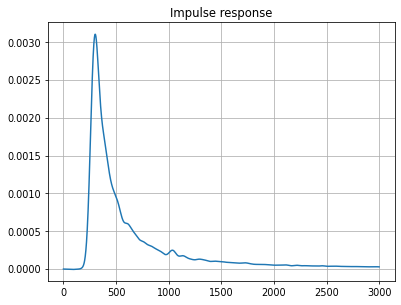

In [24]:
import sys
import os
sys.path.append(os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import skrf as rf
import scipy as sp

#load in touchstone file containing s-params of 2m copper cable connector
thru_file = "./examples/example_channel/mellitz_3ck_04_1119_CACR/Tp0_Tp5_28p5db_FQSFP_thru.s4p"
thru_network = rf.Network(thru_file)

#port definition, is defined in the header of the touchstone file
port_def = np.array([[0, 1],[2, 3]])

#for pam-4 signalling at 106.24 Gb/s
nyquist_f = 26.56e9

#time per pam-4 symbol
symbol_t = 1/(2*nyquist_f)

#oversampling ratio is 64 samples per 4-pam symbol, to get smooth eye diagrams
samples_per_symbol = 64

#compute desired timestep for impulse response
t_d = symbol_t/samples_per_symbol

#load and source impedance are matched 50 ohms, because charictaristic empedance of the the channel is 50 ohms
Zs = 50
Zl = 50

#compute differential transfer function and impulse response from s-params
H_thru, f, h_thru, t = four_port_to_diff(thru_network, port_def, Zs, Zl, option = 1, t_d = t_d)

#Plot transfer function of Channel
plt.figure(dpi = 70)
plt.plot(1e-9*f,20*np.log10(abs(H_thru)), color = "blue", label = "THRU channel", linewidth = 0.8)
plt.ylabel('Mag. Response [dB]')
plt.xlabel('Frequency [GHz]')
plt.axvline(x=26.56,color = 'grey', label = "Nyquist Frequency")
plt.title("Bode Plot")
plt.grid()
plt.legend()
plt.show()
plt.pause(1)

#visualize pulse response
pulse_response = sp.signal.fftconvolve(h_thru, np.ones(samples_per_symbol), mode = "same")
Signal.channel_coefficients(pulse_response, t, samples_per_symbol, 3, 20)

#crop impulse response and save
plt.figure(dpi = 70)
h_thru_crop = h_thru[44500:47500]
plt.plot(h_thru_crop)
plt.title("Impulse response")
plt.grid()

#save pulse response, transfer function, and frequency vector, used in other example files

#save data
np.save("./examples/example_channel/data/h_thru.npy",h_thru_crop)
np.save("./examples/example_channel/data/f.npy",f)
np.save("./examples/example_channel/data/TF_thru.npy",H_thru)

## Plotting Eye Diagrams
This EyeDiagram class provides methods for generating eye diagrams for signals.

In [25]:
"""Functions for plotting eye diagrams

"""
import numpy as np
import matplotlib.pyplot as plt

class EyeDiagram:
    @staticmethod    
    def histogram(signal, window_len, ntraces, tstep, sample_point, title, res=70):
        """Genterates simple eye diagram
    
        Parameters
        ----------
        signal: array
            signal to be plotted
        
        window_len: int
            number of time steps in eye diagram x axis
        
        ntraces: int
            number of traces to be plotted
        
        tstep: float
            timestep of time domain signal
        
        title: 
            title of the plot
            
        res: int, optional
            DPI resolution of the figure
            
        linewidth: float, optional
            width of lines in figure
        """
    
        signal_crop = signal[0:ntraces*window_len]
        traces = np.split(signal_crop,ntraces)
    
        t = np.linspace(-(tstep*(window_len-1))/2,(tstep*(window_len-1))/2, window_len)
        signal_samples = []
        
        for i in range(ntraces):
            signal_samples.append(np.reshape((traces[i][:]),window_len)[sample_point])

        # Generate x-values based on the index of the signal data
        x_values = np.arange(len(signal_samples))
        # Create scatter plot
        plt.figure(dpi=res)
        plt.scatter(x_values, signal_samples, s=10, alpha=0.6)
        plt.xlabel("Sample Index")
        plt.ylabel("Signal Value")
        plt.title(f"Scatter Plot: {title}")
        plt.show()

        plt.figure(dpi=res)
        plt.hist(signal_samples, bins=180, color='blue', edgecolor='black', alpha=0.4)
        # Add titles and labels
        plt.title(f"Histogram Plot: {title}")
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        # Show the plot
        plt.show()
        plt.pause(1)

        return signal_samples
    
    @staticmethod    
    def simple_eye(signal, window_len, ntraces, tstep, title, res=70, linewidth=0.15):
        """Genterates simple eye diagram
    
        Parameters
        ----------
        signal: array
            signal to be plotted
        
        window_len: int
            number of time steps in eye diagram x axis
        
        ntraces: int
            number of traces to be plotted
        
        tstep: float
            timestep of time domain signal
        
        title: 
            title of the plot
            
        res: int, optional
            DPI resolution of the figure
            
        linewidth: float, optional
            width of lines in figure
        """
    
        signal_crop = signal[0:ntraces*window_len]
        traces = np.split(signal_crop,ntraces)
    
        t = np.linspace(-(tstep*(window_len-1))/2,(tstep*(window_len-1))/2, window_len)
        
        plt.figure(dpi=res)
        for i in range(ntraces):
            plt.plot(t*1e12,np.reshape((traces[i][:]),window_len), color = 'blue', linewidth = linewidth)
            plt.title(title)
            plt.xlabel('[ps]')
            plt.ylabel('[V]')
        plt.show()
        plt.pause(1)
        
        return True

    @staticmethod
    def rx_jitter_eye(signal, window_len, ntraces, n_symbols, tstep, title,  stdev, res=70, linewidth=0.15,):
        """Genterates eye diagram with jitter introduved by splitting traces and applying 
        horizontal shift with gaussian distribution
    
        Parameters
        ----------
        signal: array
            signal to be plotted
        
        window_len: int
            number of time steps in eye diagram x axis
        
        ntraces: int
            number of traces to be plotted
        
        tstep: float
            timestep of time domain signal
        
        title: 
            title of the plot
            
        stdev: float
            RMS value of gaussian jitter
        
        res: int, optional
            DPI resolution of the figure
            
        linewidth: float, optional
            width of lines in figure
        """
        epsilon = np.random.normal(0,stdev,n_symbols)
        
        epsilon.clip(window_len*tstep)
        epsilon[0]=0
        
        signal_crop = signal[0:ntraces*window_len]
        traces = np.split(signal_crop,ntraces)
        
        plt.figure(dpi=res)
        for symbol_index,symbol_epsilon in enumerate(epsilon):
            epsilon_duration = int(round(symbol_epsilon/tstep))
            t = np.linspace( -tstep * (((window_len-1))/2 + epsilon_duration ) ,tstep * (((window_len-1))/2 + epsilon_duration ), window_len)
            plt.plot(t*1e12,np.reshape((traces[symbol_index][:]),window_len), color = 'blue', linewidth = linewidth)
        
            
        plt.title(title)
        plt.xlabel('[ps]')
        plt.ylabel('[V]')
        plt.xlim([-tstep*1e12*(window_len)/2, tstep*1e12* (window_len)/2])
        plt.show()
        plt.pause(1)
        
        return True

    @staticmethod
    def measure_eye(signal, window_len, ntraces):
        signal_crop = signal[0:ntraces*window_len]
        traces = np.split(signal_crop,ntraces)
        symbols = []
        for i in range(ntraces):
            symbols.append(np.reshape((traces[i][:]), window_len))
        # Measure Eye Height (Vertical Opening)
        center_idx = window_len // 2  # Assuming center is middle of symbol period
        eye_height = np.max(symbols[center_idx]) - np.min(symbols[center_idx])

        # Measure Eye Width (Horizontal Opening)
        samples_per_bit = window_len
        num_samples = len(signal)
        num_bits = num_samples // samples_per_bit
        mid_point = samples_per_bit // 2
        eye_openings = []
    
        for i in range(num_bits - 1):
            segment = signal[i * samples_per_bit:(i + 2) * samples_per_bit]
            eye_opening = np.max(segment[mid_point:mid_point + samples_per_bit]) - np.min(segment[mid_point:mid_point + samples_per_bit])
            eye_openings.append(eye_opening)
    
        eye_width = np.mean(eye_openings)
   
        return eye_height, eye_width

    @staticmethod
    def measure_eye_width(signal, symbol_rate):
        # Assuming signal is normalized and centered around 0
        zero_crossings = np.where(np.diff(np.sign(signal)))[0]
        eye_widths = np.diff(zero_crossings) / symbol_rate
        average_eye_width = np.mean(eye_widths)
        return average_eye_width

## Pseudo-Random Sequences
This Prs class provides methods for generating and checking various Pseudo-Random Binary Sequences (PRBS).

In [26]:
import numpy as np 

class Prs:
    @staticmethod    
    def prbs31(seed):
        """Genterates PRBS31 sequence
        The function generates a PRBS31 sequence, which is commonly used in communication systems
        for testing purposes. The sequence is generated using a Linear Feedback Shift Register (LFSR)
        with a specified seed.
    
        Parameters
        ----------
        seed : int
            seed used to generate sequence
            should be greater than 0 and less than 2^31
    
        Returns
        -------
        array:
            PRBS31 sequence
        """
        # Seed Validation
        if (type(seed)!= int) or (seed>0x7fffffff) or (seed < 1):
            print("seed must be positive int less than 2^31")
            return False
        
        code = seed
        # seq: An array to store the generated PRBS sequence.
        seq = np.zeros(2**31-1, dtype=np.uint8)
        i = 0
        sequence_complete = False
        
        # Sequence Generation Loop
        while(i<2**31):
            # next_bit: Computes the next bit in the sequence by XOR-ing the 31st and 28th bits of code
            # and taking the least significant bit.
            next_bit = ((code>>30) ^ (code>>27)) & 0x00000001
            # code: Updates the LFSR by shifting left and inserting next_bit.
            code = ((code<<1) | next_bit) & 0x7fffffff
            seq[i] = next_bit
            i = i+1
            if (i%1e6 ==0):
                print("i =", i)
            # Completion Check: If the LFSR returns to the seed value, sets sequence_complete to True and breaks the loop.
            if (code==seed):
                sequence_complete = True
                break
            
        if sequence_complete:
            return seq
        else:
            print ("error, PRBS sequence did not complete")
            return False
    
    @staticmethod    
    def prbs24(seed):
    
        if (type(seed)!= int) or (seed>2**22) or (seed < 1):
            print("seed must be positive int less than 2^26")
            return False
        
        code = seed
        seq = np.zeros(2**24-1, dtype=np.uint8)
        i = 0
        sequence_complete = False
        
        while(i<2**24):
            next_bit = ((code>>23) ^ (code>>22)^(code>>21)^(code>>16)) & 0x000001
            code = ((code<<1) | next_bit) & 0xffffff
            seq[i] = next_bit
            i = i+1
            #if (i%1e6 ==0):
            #    print("i =", i)
            if (code==seed):
                sequence_complete = True
                break
            
        if sequence_complete:
            return seq
        else:
            print ("error, PRBS sequence did not complete")
            return False
    
    @staticmethod    
    def prbs22(seed):
    
        if (type(seed)!= int) or (seed>2**22) or (seed < 1):
            print("seed must be positive int less than 2^26")
            return False
        
        code = seed
        seq = np.zeros(2**22-1, dtype=np.uint8)
        i = 0
        sequence_complete = False
        
        while(i<2**22):
            next_bit = ((code>>21) ^ (code>>20)) & 0x000001
            code = ((code<<1) | next_bit) & 0x3fffff
            seq[i] = next_bit
            i = i+1
            #if (i%1e6 ==0):
            #    print("i =", i)
            if (code==seed):
                sequence_complete = True
                break
            
        if sequence_complete:
            return seq
        else:
            print ("error, PRBS sequence did not complete")
            return False
    
    @staticmethod    
    def prbs20(seed):
        """Genterates PRBS20 sequence
    
        Parameters
        ----------
        seed : int
            seed used to generate sequence
            should be greater than 0 and less than 2^20
    
        Returns
        -------
        array:
            PRBS20 sequence
        """
        if (type(seed)!= int) or (seed>0xfffff) or (seed < 1):
            print("seed must be positive int less than 2^20")
            return False
        
        code = seed
        seq = np.zeros(2**20-1, dtype=np.uint8)
        i = 0
        sequence_complete = False
        
        while(i<2**20):
            next_bit = ((code>>19) ^ (code>>2)) & 0x00001
            code = ((code<<1) | next_bit) & 0xfffff
            seq[i] = next_bit
            i = i+1
            if (code==seed):
                sequence_complete = True
                break
            
        if sequence_complete:
            return seq
        else:
            print ("error, PRBS sequence did not complete")
            return False
    
    @staticmethod    
    def prbs13(seed):
        """Genterates PRBS13 sequence
    
        Parameters
        ----------
        seed : int
            seed used to generate sequence
            should be greater than 0 and less than 2^13
    
        Returns
        -------
        array:
            PRBS13 sequence
        """
        if (type(seed)!= int) or (seed>0x1fff) or (seed < 1):
            print("seed must be positive int less than 2^13")
            return False
        
        code = seed
        seq = np.zeros(2**13-1, dtype=np.uint8)
        i = 0
        sequence_complete = False
        
        while(i<2**13):
            next_bit = ((code>>12) ^ (code>>11) ^ (code>>1) ^ (code) ) & 0x00001
            code = ((code<<1) | next_bit) & 0x1fff
            seq[i] = next_bit
            i = i+1
            if (code==seed):
                sequence_complete = True
                break
            
        if sequence_complete:
            return seq
        else:
            print ("error, PRBS sequence did not complete")
            return False
    
    @staticmethod    
    def prbs7(seed):
        """Genterates PRBS7 sequence
    
        Parameters
        ----------
        seed : int
            seed used to generate sequence
            should be greater than 0 and less than 2^7
    
        Returns
        -------
        array:
            PRBS7 sequence
        """
        if (type(seed)!= int) or (seed>0x7f) or (seed < 1):
            print("seed must be positive int less than 2^7")
            return False
        
        code = seed
        seq = np.zeros(2**7-1, dtype=np.uint8)
        i = 0
        sequence_complete = False
        
        while(i<2**7):
            next_bit = ((code>>6) ^ (code>>5))&0x01
            code = ((code<<1) | next_bit) & 0x7f
            seq[i] = next_bit
            i = i+1
            if (code==seed):
                sequence_complete = True
                break
            
        if sequence_complete:
            return seq
        else:
            print ("error, PRBS sequence did not complete")
            return False
    
    @staticmethod    
    def prqs10(seed):
        """Genterates PRQS10 sequence
        This function aims to generate a PRQS10 (Pseudo-Random Quadrature Sequence) sequence using a seed value.
        This involves generating a PRBS20 sequence, shifting it, combining it, and then encoding it using a Gray code.
    
        Parameters
        ----------
        seed : int
            seed used to generate sequence
            should be greater than 0 and less than 2^20
    
        Returns
        -------
        array:
            PRQS10 sequence
        """
        
        a = Prs.prbs20(seed)
        # Shift and Stack Sequence
        shift = int((2**20-1)/3)
        b = np.hstack((a[shift:],a[:shift]))
        
        c = np.vstack((a,b))
    
        pqrs = np.zeros(a.size,dtype = np.uint8)
        
        for i in range(a.size):
            pqrs[i] = Signal.grey_encode(c[:,i])
        
        return pqrs
    
    
    @staticmethod    
    def prqs12(seed):
        
        a = Prs.prbs24(seed)
        shift = int((2**24-1)/3)
        b = np.hstack((a[shift:],a[:shift]))
        
        c = np.vstack((a,b))
    
        pqrs = np.zeros(a.size,dtype = np.uint8)
        
        for i in range(a.size):
            if (i%1e5 == 0):
                print("i =", i)
            pqrs[i] = Prs.grey_encode(c[:,i])
        
        return pqrs
    
    
    
    @staticmethod    
    def prbs_checker(n, prbs, data):
        """Compares array with PRBS array to check bit errors
        The prbs_checker function compares a given data sequence with a PRBS sequence to identify and count bit errors.
    
        Parameters
        ----------
        n : int
            prbs_n number
        
        prbs : array
            prbs_n sequence
            
        data: array
            seqence to be checked
    
        Returns
        -------
        error_count : int
            number of errors in data
            
        error_idx :  list
            indexes of error bits in data
        """
        #TODO: add condition when there is an error in the first n bits
        
        # test: A copy of the first n bits of the data sequence.
        test = np.copy(data[:n])
        
        start_idx = -1
        
        # Finding the Start Index
        # Loops through the PRBS sequence to find a segment that matches the first n bits of the data.
        for i in range (prbs.size):
            if np.array_equal(prbs[i:i+n], test):
                start_idx = i
                break
            
        if start_idx == -1:
            print ("invalid prbs_seq or incorrect n")
            return False
        
        #print(start_idx)
        
        # Counting Errors
        error_count = 0
        
        error_idx = []
        
        # Loops through the data sequence to compare each bit with the corresponding bit in the PRBS sequence.
        # If more than one-third of the first 1000 bits are errors, it prints an error message and returns False.
        for i in range(data.size):
            if (data[i] != prbs[(start_idx+i)%(2**n-1)]):
                error_count = error_count+1
                error_idx = error_idx + [i]
            if (i==1000) and (error_count>333):
                print ("Either error in first n bits of data, or too many errors in data (more than 1/3 or bits are errors)")
                return False
        
        return [error_count, error_idx]
    
    
    @staticmethod    
    def prqs_checker(n, prqs, data):
        """Compares array with PRQS array to check bit errors
    
        Parameters
        ----------
        n : int
            prqs_n number
        
        prqs : array
            prqs_n sequence
            
        data: array
            seqence to be checked
    
        Returns
        -------
        error_count : int
            number of errors in data
            
        error_idx :  list
            indexes of error bits in data
        """
        #TODO: add condition when there is an error in the first n bits
        
        test = np.copy(data[:n])
        
        start_idx = -1
        
        for i in range (prqs.size):
            if np.array_equal(prqs[i:i+n], test):
                start_idx = i
                break
            
        if start_idx == -1:
            print ("invalid prqs or incorrect n")
            return False
        
        #print(start_idx)
        
        error_count = 0
        
        error_idx = []
        
        for i in range(data.size):
            if (data[i] != prqs[(start_idx+i)%(2**(n*2)-1)]):
                if (abs(data[i]-prqs[(start_idx+i)%(2**(n*2)-1)]) == 2):
                    #print('2 errors')
                    error_count = error_count+2
                else:
                    error_count = error_count+1
                error_idx = error_idx + [i]
        
        return [error_count, error_idx]

## Example
Here is the complete example code:

In [27]:
import numpy as np

# Define the seed for the PRBS7 sequence
seed = 123

# Generate the PRBS7 sequence
prbs7_sequence = Prs.prbs7(seed)

# Print the first 20 elements of the PRBS7 sequence
print("PRBS7 Sequence (first 20 elements):", prbs7_sequence[:20])

# Create a data sequence by copying the PRBS7 sequence
data_sequence = np.copy(prbs7_sequence)

# Introduce some errors in the data sequence
data_sequence[10] = 1 if data_sequence[10] == 0 else 0
data_sequence[25] = 1 if data_sequence[25] == 0 else 0
data_sequence[30] = 1 if data_sequence[30] == 0 else 0

# Print the first 40 elements of the data sequence
print("Data Sequence (first 40 elements):", data_sequence[:40])

# Use the prbs_checker method to identify bit errors
errors = Prs.prbs_checker(7, prbs7_sequence, data_sequence)

# Print the error count and error indexes
if errors:
    print("Error count:", errors[0])
    print("Error indexes:", errors[1])


PRBS7 Sequence (first 20 elements): [0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 0 0]
Data Sequence (first 40 elements): [0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 1 1 1 1 1 1
 0 0 0]
Error count: 3
Error indexes: [10, 25, 30]


## Generate 2-PAM and 4-PAM PRBS waveforms
Generate 2-PAM and 4-PAM PRBS waveforms at 50 & 100Gbps with 64 samples per UI. Filter each of the waveforms with first-order low-pass filters having a cut-off frequency of 20, 30, 40,
and 50GHz. Plot the eye diagrams.

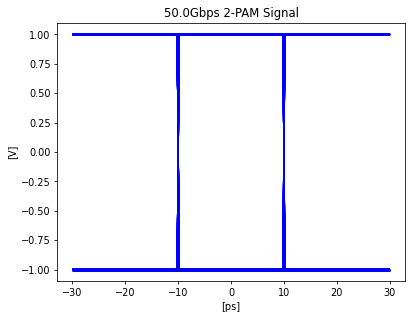

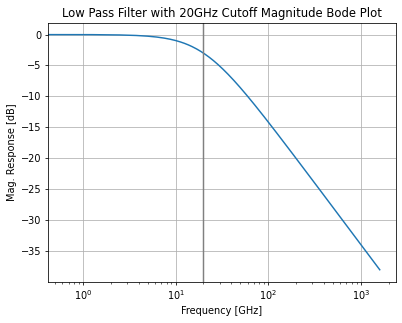

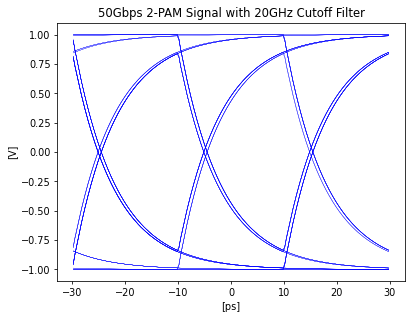

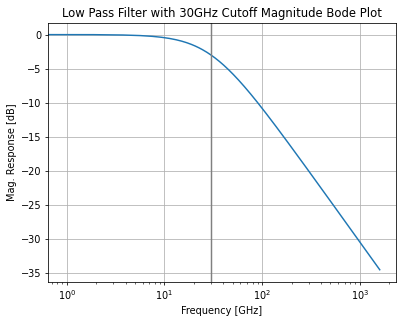

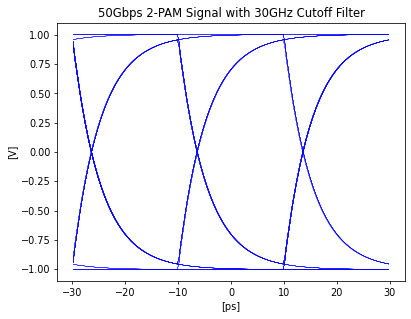

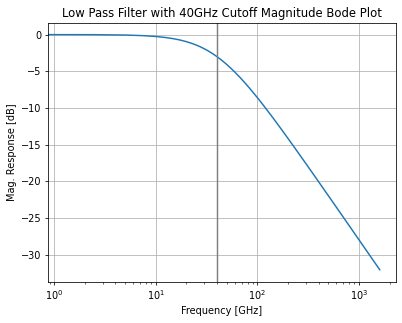

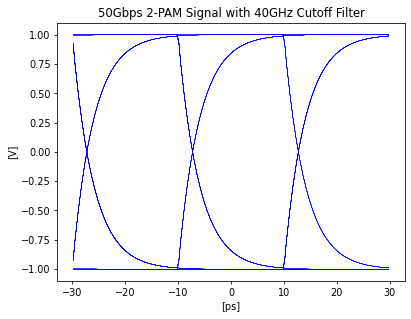

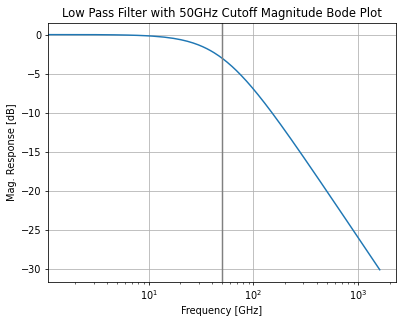

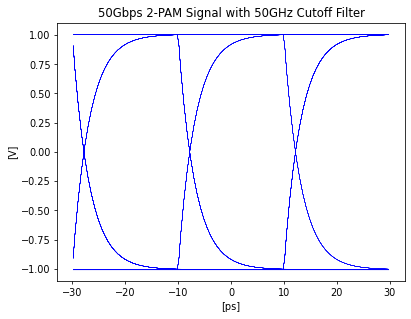

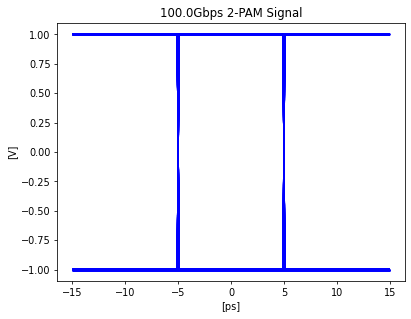

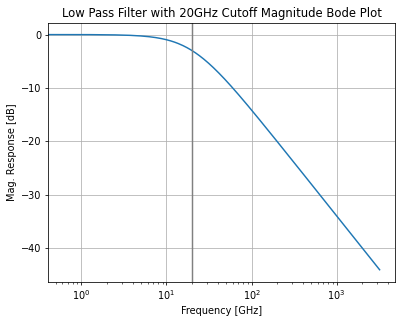

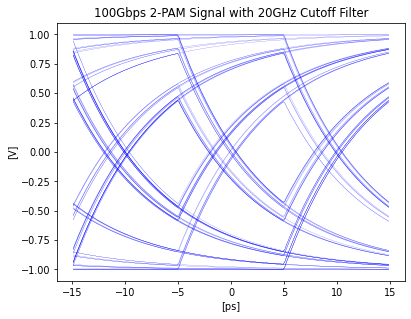

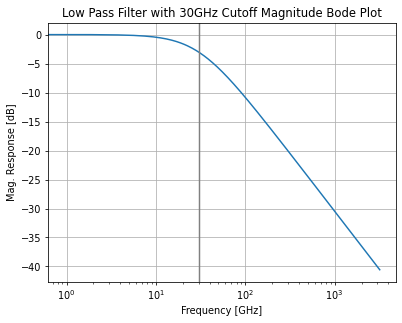

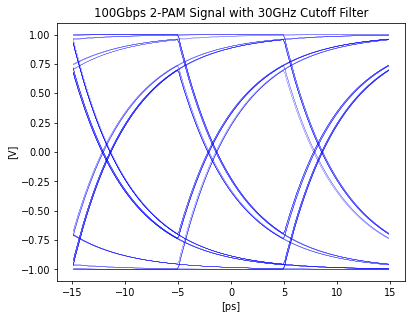

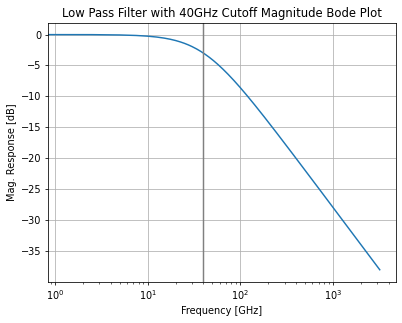

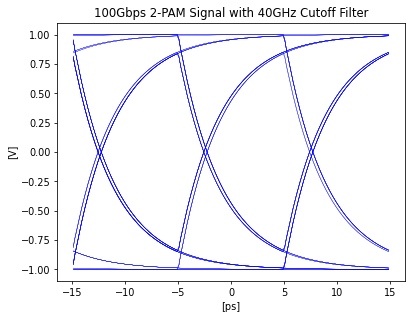

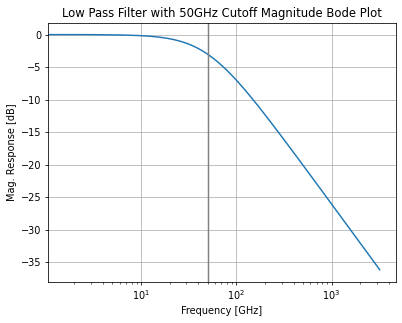

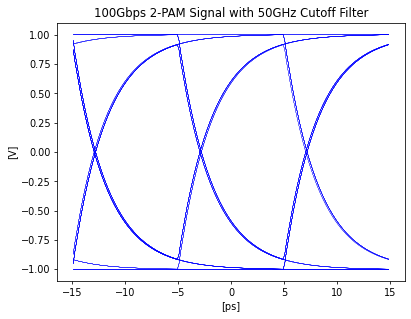

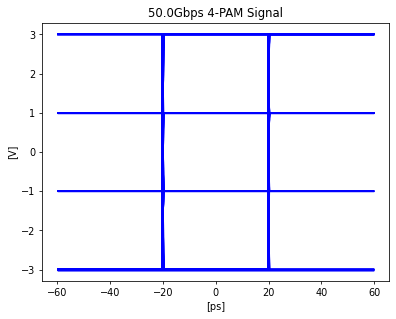

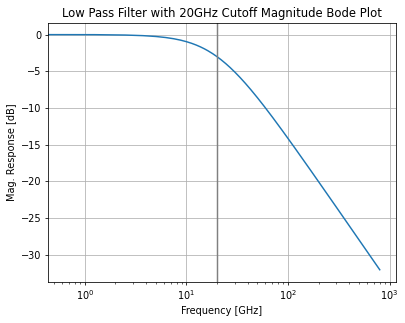

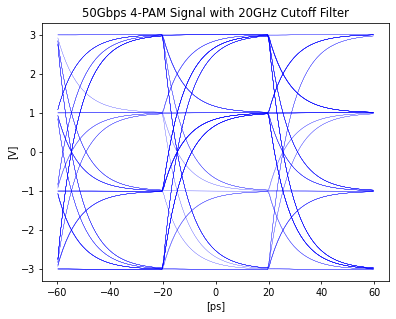

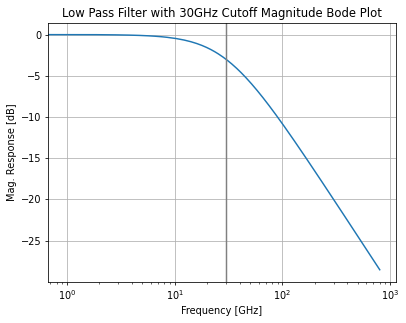

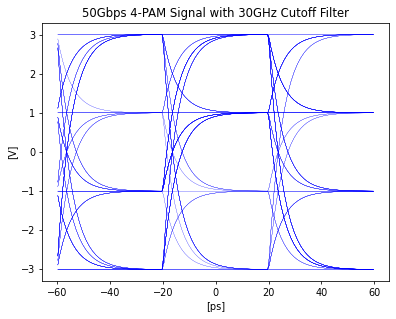

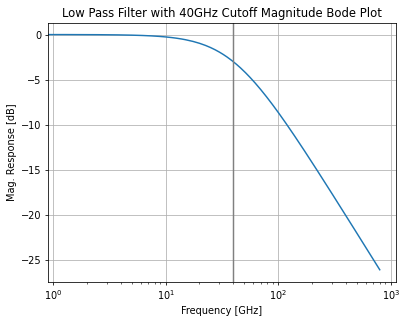

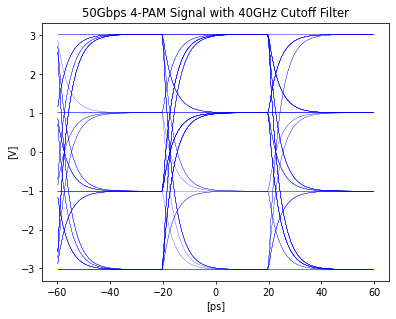

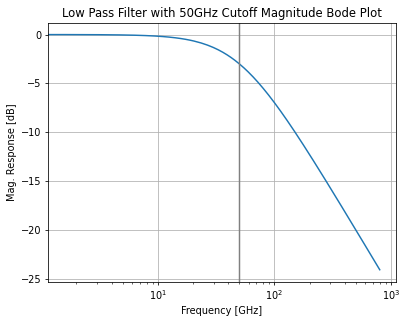

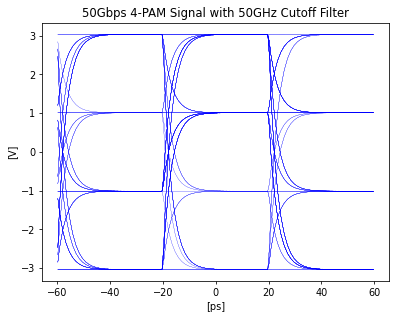

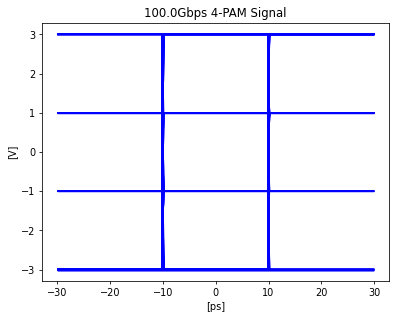

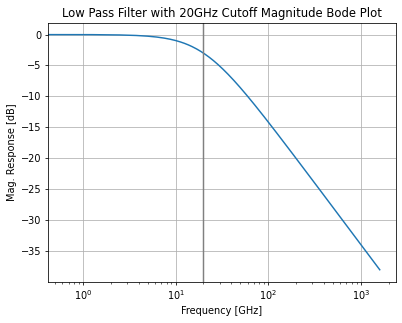

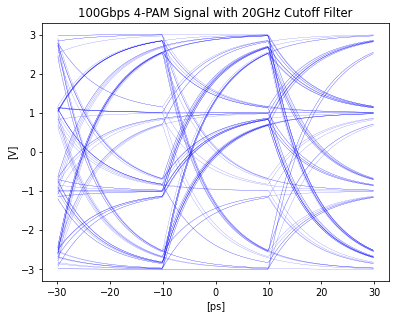

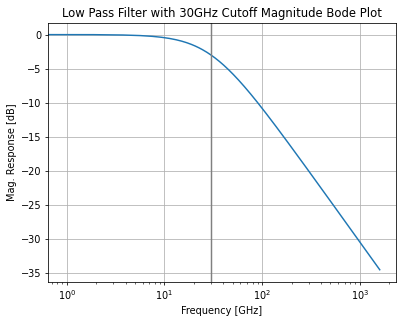

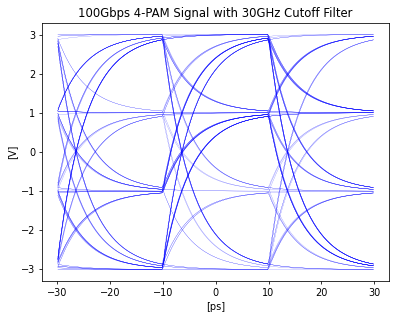

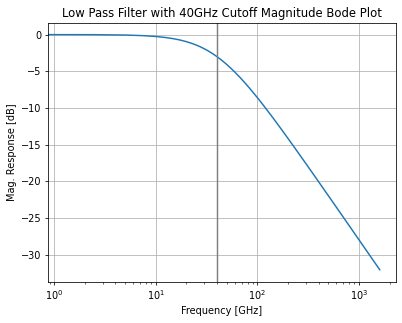

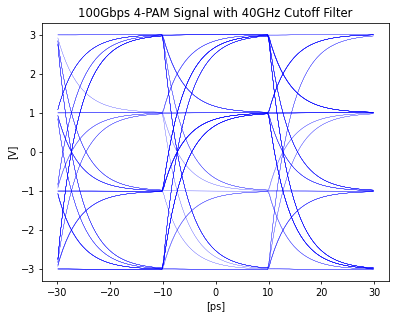

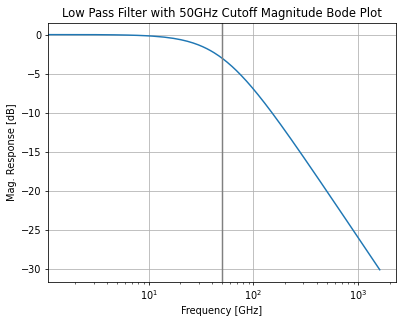

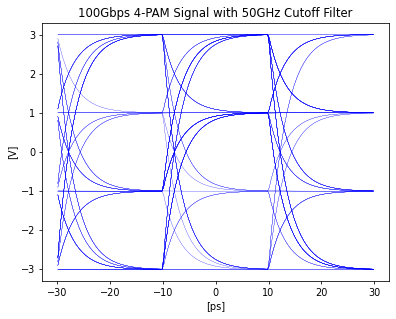

In [28]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt


#%% 2-PAM 

#generate binary data
data = Prs.prbs13(1)
     
#generate Baud-Rate sampled signal from data
signal_BR = Signal.nrz_input_BR(data)
    
#data rate in Gbps
for data_rate in [50e9,100e9]:
    
    #time per bit
    UI = 1/data_rate
    
    #define oversample ratio
    samples_per_symbol = 64
    
    #timestep
    dt = UI/samples_per_symbol

    #oversampled signal
    signal_ideal = np.repeat(signal_BR, samples_per_symbol)
    
    #eye diagram of ideal signal
    EyeDiagram.simple_eye(signal_ideal, samples_per_symbol*3, 100, dt, "{}Gbps 2-PAM Signal".format(data_rate/1e9),linewidth=1.5)

    #cutoff frequency
    for freq_bw in [20e9, 30e9, 40e9, 50e9]:
               
        #max frequency for constructing discrete transfer function
        max_f = 1/dt
        
        #max_f in rad/s
        max_w = max_f*2*np.pi
        
        #heuristic to get a reasonable impulse response length
        ir_length = int(4/(freq_bw*dt))
        
        #calculate discrete transfer function of low-pass filter with pole at freq_bw
        w, H = sp.signal.freqs([freq_bw*(2*np.pi)], [1,freq_bw*(2*np.pi)], np.linspace(0,0.5*max_w,ir_length*4))
        
        #frequency vector for discrete transfer function in hz
        f = w/(2*np.pi)
        
        #plot frequency response of the low-pass filter
        plt.figure(dpi=70)
        plt.semilogx(1e-9*f,20*np.log10(abs(H)))
        plt.ylabel('Mag. Response [dB]')
        plt.xlabel('Frequency [GHz]')
        plt.title("Low Pass Filter with {}GHz Cutoff Magnitude Bode Plot".format(round(freq_bw*1e-9)))
        plt.grid()
        plt.axvline(x=1e-9*freq_bw,color = 'grey')
        plt.show()
        plt.pause(1)
        
        #find impluse response of low-pass filter
        h, t = ChModel.freq2impulse(H,f)
        
        #plot impulse response of the low-pass filter 
        # plt.figure(dpi=70)
        # plt.plot(t[:ir_length]*1e12,h[:ir_length])
        # plt.title("Low Pass Filter with {}GHz Cutoff Impulse Response".format(round(freq_bw*1e-9)))
        # plt.xlabel('Time [ps]')
        # plt.ylabel('[V]')
        # plt.show()
        
        signal_filtered = sp.signal.fftconvolve(signal_ideal, h[:ir_length], mode="full")
        
        EyeDiagram.simple_eye(signal_filtered[samples_per_symbol*100:], samples_per_symbol*3, 100, UI/samples_per_symbol, "{}Gbps 2-PAM Signal with {}GHz Cutoff Filter".format(round(data_rate/1e9),round(freq_bw*1e-9)))

#%% 4-PAM

#generate binary data
data = Prs.prqs10(1)[:10000]
     
#generate Baud-Rate sampled signal from data
signal_BR = Signal.pam4_input_BR(data)
    
#data rate in Gbps
for data_rate in [50e9,100e9]:
    
    #time per 4-PAM symbol
    UI = 2/data_rate
    
    #define oversample ratio
    samples_per_symbol = 64
    
    #timestep
    dt = UI/samples_per_symbol

    #oversampled signal
    signal_ideal = np.repeat(signal_BR, samples_per_symbol)
    
    #eye diagram of ideal signal
    EyeDiagram.simple_eye(signal_ideal, samples_per_symbol*3, 100, dt, "{}Gbps 4-PAM Signal".format(data_rate/1e9),linewidth=1.5)
    
    #cutoff frequency
    for freq_bw in [20e9, 30e9, 40e9, 50e9]:
               
        #max frequency for constructing discrete transfer function
        max_f = 1/dt
        
        #max_f in rad/s
        max_w = max_f*2*np.pi
        
        #heuristic to get a reasonable impulse response length
        ir_length = int(4/(freq_bw*dt))
        
        #calculate discrete transfer function of low-pass filter with pole at freq_bw
        w, H = sp.signal.freqs([freq_bw*(2*np.pi)], [1,freq_bw*(2*np.pi)], np.linspace(0,0.5*max_w,ir_length*4))
        
        #frequency in hz
        f = w/(2*np.pi)
        
        #plot frequency response of TF
        plt.figure(dpi=70)
        plt.semilogx(1e-9*f,20*np.log10(abs(H)))
        plt.ylabel('Mag. Response [dB]')
        plt.xlabel('Frequency [GHz]')
        plt.title("Low Pass Filter with {}GHz Cutoff Magnitude Bode Plot".format(round(freq_bw*1e-9)))
        plt.grid()
        plt.axvline(x=1e-9*freq_bw,color = 'grey')
        plt.show()
        
        #find impluse response of low-pass filter
        h, t = ChModel.freq2impulse(H,f)
        
        #plot impulse response of the low-pass filter 
        # plt.figure(dpi=70)
        # plt.plot(t[:ir_length]*1e12,h[:ir_length])
        # plt.title("Low Pass Filter with {}GHz Cutoff Impulse Response".format(round(freq_bw*1e-9)))
        # plt.xlabel('Time [ps]')
        # plt.ylabel('[V]')
        # plt.show()
        
        signal_filtered = sp.signal.fftconvolve(signal_ideal, h[:ir_length], mode="full")
        
        EyeDiagram.simple_eye(signal_filtered[samples_per_symbol*100:], samples_per_symbol*3, 100, UI/samples_per_symbol, "{}Gbps 4-PAM Signal with {}GHz Cutoff Filter".format(round(data_rate/1e9),round(freq_bw*1e-9)))

## CTLE modelling
This file shows example of CTLE modelling, and generates the impulse response of the channel and CTLE 

Requires running 1_channel.py first

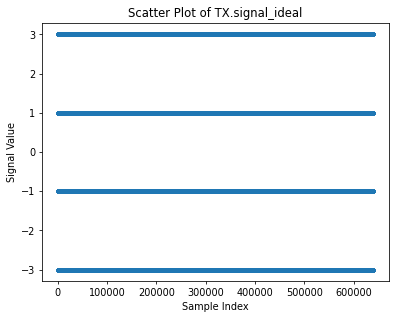

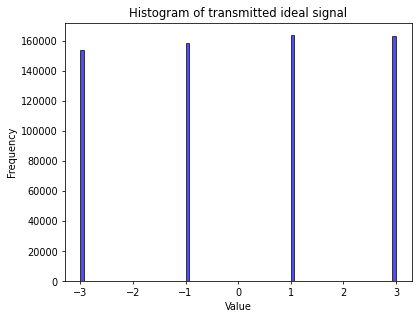

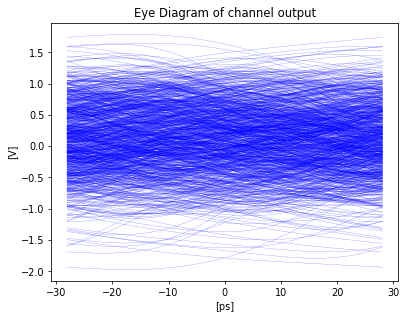

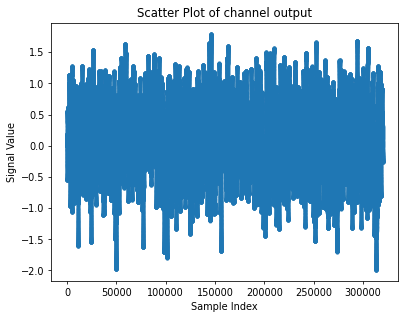

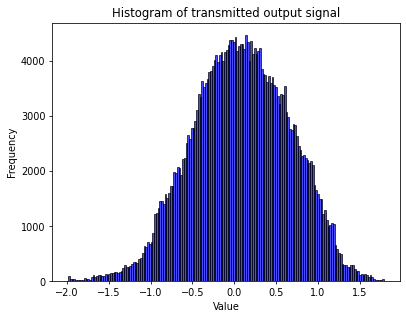

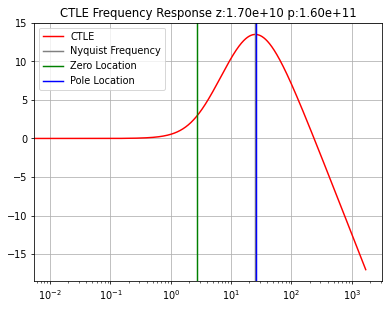

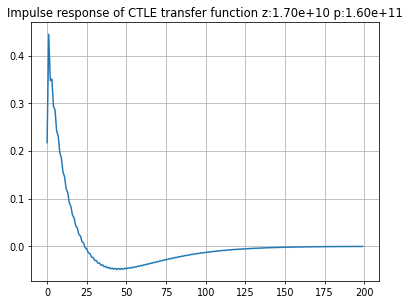

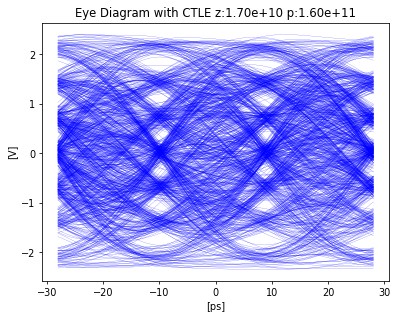

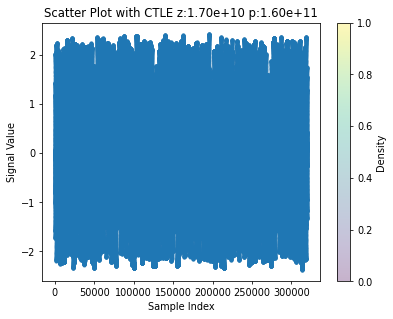

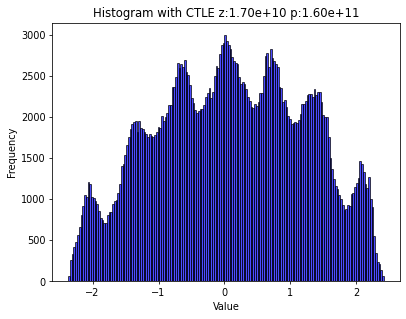

Eye Diagram with CTLE Height: 0.5456048493646874
Eye Diagram with CTLE Width: 2.2399918454883445
Eye Diagram with CTLE Width: 0.8108113606770833


In [29]:
#import useful packages
import sys
import os
sys.path.append(os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import gaussian_kde

scatter_s = 10
scatter_alpha = 0.3


#load in data generated by 1_channel.py
f = np.load("./examples/example_channel/data/f.npy")
h = np.load("./examples/example_channel/data/h_thru.npy")
H = np.load("./examples/example_channel/data/TF_thru.npy")

#frequency vector in rad/s
w = f*(2*np.pi)

#oversampling ratio used in 1_channel.py
samples_per_symbol = 64

#%% plot eye diagram with and without CTLE
voltage_levels = np.array([-3,-1,1,3])

nyquist_f = 26.56e9

data = Prs.prqs10(1)

TX = Transmitter(data[:10000], voltage_levels, nyquist_f)

TX.oversample(samples_per_symbol)

# Generate x-values based on the index of the signal data
x_values = np.arange(len(TX.signal_ideal))
# Create scatter plot
plt.figure(dpi=70)
plt.scatter(x_values, TX.signal_ideal, s=scatter_s, alpha=scatter_alpha)  # Adjust size (`s`) and transparency (`alpha`) if needed
plt.xlabel("Sample Index")
plt.ylabel("Signal Value")
plt.title("Scatter Plot of TX.signal_ideal")
plt.show()

# Plot the histogram
plt.figure(dpi=70)
plt.hist(TX.signal_ideal, bins=90, color='blue', edgecolor='black', alpha=0.7)
# Add titles and labels
plt.title('Histogram of transmitted ideal signal')
plt.xlabel('Value')
plt.ylabel('Frequency')
# Show the plot
plt.show()

signal_out = sp.signal.fftconvolve(TX.signal_ideal, h, mode = "same")[:64*1000*5]

EyeDiagram.simple_eye(signal_out[1000:], samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, "Eye Diagram of channel output")

# Generate x-values based on the index of the signal data
x_values = np.arange(len(signal_out))
# Create scatter plot
plt.figure(dpi=70)
plt.scatter(x_values, signal_out, s=scatter_s, alpha=scatter_alpha)  # Adjust size (`s`) and transparency (`alpha`) if needed
plt.xlabel("Sample Index")
plt.ylabel("Signal Value")
plt.title("Scatter Plot of channel output")
plt.show()

# Plot the histogram
plt.figure(dpi=70)
plt.hist(signal_out, bins=180, color='blue', edgecolor='black', alpha=0.7)
# Add titles and labels
plt.title('Histogram of transmitted output signal')
plt.xlabel('Value')
plt.ylabel('Frequency')
# Show the plot
plt.show()

####################
# CTLE
#set poles and zeroes for peaking at nyquist freq
#high peaking because channel is high insertion loss
z = 2e10 #5e9 #2e10
p = 1.7e11 #7.7e10 #1.7e11


#for z in np.arange(1.4e10, 2.2e10, 1e9):
#    for p in np.arange(1.2e11, 1.9e11, 0.2e11):
for z in np.arange(1.7e10, 1.8e10, 1e9):
    for p in np.arange(1.6e11, 1.7e11, 0.2e11):
        k = p**2/z
        
        #calculate Frequency response of CTLE at given frequencies
        w, H_ctle = sp.signal.freqs([k/p**2, k*z/p**2], [1/p**2, 2/p, 1], w)
        
        #bode plot of CTLE transfer function
        plt.figure(dpi=70)
        plt.semilogx(1e-9*f,20*np.log10(abs(H_ctle)), color = "red", label = 'CTLE')
        plt.title(f"CTLE Frequency Response z:{z:.2e} p:{p:.2e}")
        plt.grid()
        plt.axvline(x=25,color = 'grey', label = "Nyquist Frequency")
        plt.axvline(x=z/(2*np.pi)*1e-9,color = 'green', label = "Zero Location")
        plt.axvline(x=p/(2*np.pi)*1e-9,color = 'blue', label = "Pole Location")
        plt.legend()
        
        #%% compute and save impulse response of CTLE transfer function
        h_ctle, t_ctle = ChModel.freq2impulse(H_ctle,f)
        h_ctle = h_ctle[0:200]
        plt.figure(dpi=70)
        plt.plot(h_ctle)
        plt.title(f"Impulse response of CTLE transfer function z:{z:.2e} p:{p:.2e}")
        plt.grid()
        
        np.save("./examples/example_channel/data/h_ctle.npy", h_ctle)
        
        signal_out_ctle = sp.signal.fftconvolve(signal_out, h_ctle, mode = "same")
        
        EyeDiagram.simple_eye(signal_out_ctle[1000:], samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, f"Eye Diagram with CTLE z:{z:.2e} p:{p:.2e}")
        
        # Generate x-values based on the index of the signal data
        x_values = np.arange(len(signal_out_ctle))
        # Create scatter plot
        plt.figure(dpi=70)
        plt.scatter(x_values, signal_out_ctle, s=scatter_s, alpha=scatter_alpha)
        plt.colorbar(label="Density")


        plt.xlabel("Sample Index")
        plt.ylabel("Signal Value")
        plt.title(f"Scatter Plot with CTLE z:{z:.2e} p:{p:.2e}")
        plt.show()
        
        # Plot the histogram
        plt.figure(dpi=70)
        plt.hist(signal_out_ctle, bins=180, color='blue', edgecolor='black', alpha=0.7)
        # Add titles and labels
        plt.title(f'Histogram with CTLE z:{z:.2e} p:{p:.2e}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        # Show the plot
        plt.show()
        
        eye_height, eye_width = EyeDiagram.measure_eye(signal_out_ctle[1000:], samples_per_symbol*3, 1000)
        print(f"Eye Diagram with CTLE Height: {eye_height}")
        print(f"Eye Diagram with CTLE Width: {eye_width}")
        eye_width = EyeDiagram.measure_eye_width(signal_out_ctle[1000:], samples_per_symbol*3)
        print(f"Eye Diagram with CTLE Width: {eye_width}")
        
        
        # Compute histogram bins based on the range of the data
        data_min = np.min(TX.signal_ideal)
        data_max = np.max(TX.signal_ideal)
        bin_edges = np.arange(data_min, data_max + 1)  # Adjust as needed
        
        # Compute histogram
        h, edges = np.histogram(TX.signal_ideal, bins=bin_edges)
        
        ## Plot histogram
        #plt.bar(edges[:-1], h, width=np.diff(edges), edgecolor='black', align='edge')
        #plt.xlabel("Signal Value")
        #plt.ylabel("Frequency")
        #plt.title("Histogram of TX.signal_ideal")
        #plt.show()
    

## Transmitter
Class to build model of time domain signal at transmitter 

In [30]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import samplerate

class Transmitter:
    """class to build model of time domain signal at transmitter 
    Transmitter class is designed to model the time-domain signal
    at the transmitter end, initializing it with the appropriate
    data and converting it to a baud-rate-sampled voltage waveform.
    
    """
    
    def __init__(self, data, voltage_levels, frequency):
        """
        Initialize transmitter, stores data and converts to baud-rate-sampled voltage waveform
        
        Parameters
        ----------
        data : array
            Binary sequence containing {0,1} if NRZ
            Quaternary sequence containing {0,1,2,3} symbols if PAM-4
        
        voltage levels: array
            definition of voltages corresponding to symbols. 
        
        frequency: float
            2* symbol rate
        
        """
        
        #frequency and period
        self.f = frequency
        self.T = 1/self.f
        self.UI = self.T/2
        
        
        self.voltage_levels = voltage_levels
        self.data = data
        self.n_symbols = data.size
        
        
        #self.signal_FIR_BR = None
        self.FIR_enable = False
        
        #create ideal, baud-rate-sampled transmitter waveform
        if voltage_levels.size == 2:
            self.signal_BR = Signal.nrz_input_BR(data,voltage_levels)
        
        elif voltage_levels.size == 4:
            self.signal_BR = Signal.pam4_input_BR(data,voltage_levels)
        
        else:
            print ("Error: Voltage levels must have either size = 2 for NRZ signal or size = 4 for PAM4")
    
    def FIR(self, tap_weights):
        
        """Implements TX - FIR and creates  self.signal_FIR_BR = filtered, baud-rate sampled signal
        
        Parameters
        ----------
        
        tap_weights: array
            tap weights for tx fir
            last element should be 1, eg. for a 2-tap TX-FIR, with -0.1 and -0.2 coefficients, tap_weights = np.array([-0.1, -0.2, 1])
            
        """
        self.FIR_enable = True
        
        #do convolution to implement FIR
        self.signal_FIR_BR = sp.signal.fftconvolve(self.signal_BR,tap_weights, mode="same")

    def oversample(self, samples_per_symbol):
        """oversample baud-rate signal to create ideal, square transmitter waveform
        
        Parameters
        ----------
        
        samples_per_symbol:
            samples per UI of tx signal
            
        """
        
        
        self.samples_per_symbol = samples_per_symbol
        
        
        
        #TODO: use np.repeat
        
        
        #if we have FIR filtered data
        if self.FIR_enable:
            #oversampled = samplerate.resample(self.signal_FIR_BR,samples_per_symbol,converter_type='zero_order_hold')
            self.signal_ideal = np.repeat(self.signal_FIR_BR, samples_per_symbol)
        #if we are not using FIR
        else:
            #oversampled = samplerate.resample(self.signal_BR,samples_per_symbol,converter_type='zero_order_hold')
            self.signal_ideal = np.repeat(self.signal_BR, samples_per_symbol)
    
    def gaussian_jitter(self, stdev_div_UI = 0.025):
        """Generates the TX waveform from ideal, square, self.signal_ideal with jitter
    
        Parameters
        ----------
        stdev_div_UI : float
            standard deviation of jitter distribution as a pct of UI    
        """
    
        #generate random Gaussian distributed TX jitter values
        epsilon = np.random.normal(0,stdev_div_UI*self.UI,self.n_symbols)
        
        epsilon.clip(self.UI)
        epsilon[0]=0
    
        #calculate time duration of each sample
        sample_time = self.UI/self.samples_per_symbol
    
        #initializes non_ideal (jitter) array
        non_ideal = np.zeros_like(self.signal_ideal)
    
        #populates non_ideal array to create TX jitter waveform
        for symbol_index,symbol_epsilon in enumerate(epsilon):
            epsilon_duration = int(round(symbol_epsilon/sample_time))
            start = int(symbol_index*self.samples_per_symbol)
            end = int(start+epsilon_duration)
            flip=1
            if symbol_index==0:
                continue
            if symbol_epsilon<0:
                start,end=end,start
                flip=-1
            non_ideal[start:end]=flip*(self.signal_ideal[symbol_index*self.samples_per_symbol-self.samples_per_symbol]-self.signal_ideal[symbol_index*self.samples_per_symbol])
        
        #calculate TX output waveform
        self.signal = np.copy(self.signal_ideal+non_ideal)

    def tx_bandwidth(self, freq_bw = None, TF = None):
        """Passes TX signal through an LTI system to model non-ideal TX driver
        option to use custom transfer function, or use single-pole system with specified -3dB frequency 

        Parameters
        ----------
        freq_bw: float
            bandwidth frequency

        TF: list, optional
            TF[0] : numerator coefficients for tranfer function
            TF[1] : denominator coefficients for Transfer function
            
        """

        #Timestep
        dt = self.UI/self.samples_per_symbol

        #max frequency for constructing discrete transfer function
        max_f = 1/dt

        #max_f in rad/s
        max_w = max_f*2*np.pi

        #heuristic to get a reasonable impulse response length
        ir_length = int(4/(freq_bw*dt))

        #Calculate discrete transfer function
        if TF != None:
            w, H = sp.signal.freqs(TF[0], TF[1], np.linspace(0,0.5*max_w,ir_length*4))
        else:
            #calculate discrete transfer function of low-pass filter with pole at freq_bw
            w, H = sp.signal.freqs([freq_bw*(2*np.pi)], [1,freq_bw*(2*np.pi)], np.linspace(0,0.5*max_w,ir_length*4))

        #frequency vector for discrete transfer function in hz
        f = w/(2*np.pi)

        
        #plot frequency response of the low-pass filter
        plt.figure(dpi=70)
        plt.semilogx(1e-9*f,20*np.log10(abs(H)))
        plt.ylabel('Mag. Response [dB]')
        plt.xlabel('Frequency [GHz]')
        plt.title("Low Pass Filter with {}MHz Cutoff Magnitude Bode Plot".format(round(freq_bw*1e-6)))
        plt.grid()
        plt.axvline(x=1e-9*freq_bw,color = 'grey')
        plt.show()
        

        #find impluse response of low-pass filter
        h, t = ChModel.freq2impulse(H,f)

        
        #plot impulse response of the low-pass filter 
        plt.figure(dpi=70)
        plt.plot(t[:ir_length]*1e12,h[:ir_length])
        plt.title("Low Pass Filter with {}MHz Cutoff Impulse Response".format(round(freq_bw*1e-6)))
        plt.xlabel('Time [ps]')
        plt.ylabel('[V]')
        plt.show()
        

        self.signal = sp.signal.fftconvolve(h[:ir_length], self.signal)

    def resample(self,samples_per_symbol):
        """ resamples signal to new oversampling ratio

        Parameters
        ----------
        samples_per_symbol: int
            new number of samples per UI
        """
        #TODO: check this

        q = samples_per_symbol/self.samples_per_symbol

        #if (self.samples_per_symbol % q != 0):
        #    print(r'Must downsample UI with a divisor of {self.samples_per_symbol}')
        #    return False
        
        self.samples_per_symbol = samples_per_symbol
        
        self.signal = samplerate.resample(self.signal, q, 'zero_order_hold')
        
        
def gaussian_jitter(signal_ideal, UI,n_symbols,samples_per_symbol,stdev):
    """Generates the TX waveform from ideal, square, self.signal_ideal with jitter

    Parameters
    ----------
    signal_ideal: array
        ideal,square transmitter voltage waveform
    
    UI: float
        length of one unit interval in seconds
    
    n_symbols: int
        number of symbols in signal_ideal
        
    samples_per_symbol: int
        number of samples in signal_ideal corresponding to one UI
        
    stdev:
        standard deviation of gaussian jitter in seconds
    
    stdev_div_UI : float
        standard deviation of jitter distribution as a pct of UI    
    """

    #generate random Gaussian distributed TX jitter values
    epsilon = np.random.normal(0,stdev,n_symbols)
    
    epsilon.clip(UI)
    epsilon[0]=0

    #calculate time duration of each sample
    sample_time = UI/samples_per_symbol

    #initializes non_ideal (jitter) array
    non_ideal = np.zeros_like(signal_ideal)

    #populates non_ideal array to create TX jitter waveform
    for symbol_index,symbol_epsilon in enumerate(epsilon):
        epsilon_duration = int(round(symbol_epsilon/sample_time))
        start = int(symbol_index*samples_per_symbol)
        end = int(start+epsilon_duration)
        flip=1
        if symbol_index==0:
            continue
        if symbol_epsilon<0:
            start,end=end,start
            flip=-1
        non_ideal[start:end]=flip*(signal_ideal[symbol_index*samples_per_symbol-samples_per_symbol]-signal_ideal[symbol_index*samples_per_symbol])
    
    #calculate TX output waveform
    signal = np.copy(signal_ideal+non_ideal)
    return signal


## Receiver
This Receiver class is designed to model the behavior of a time-domain signal at a receiver, particularly for communication systems using techniques like PAM-4 or NRZ signaling.

In [31]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt


class Receiver:
    """Class to build model of time domain signal at receiver 
    
    """
    
    def __init__(self, signal, samples_per_symbol, f_nyquist , voltage_levels, shift = True, main_cursor = 1):
        """Initialize Receiver
    
        Parameters
        ----------
        signal : array
            The voltage waveform at the input to the receiver, post Continuous Time Linear Equalizer (CTLE).
        
        samples_per_symbol:
            Number of samples per Unit Interval (UI), indicating the granularity of the signal sampling.
        f_nyquist: The Nyquist frequency, which is half the sampling rate.
        
        t_step:
            timestep of signal
        
        voltage_levels: Array representing the discrete voltage levels for PAM4 symbols.
            
        shift : bool
            A boolean indicating whether to shift the signal such that the center of the eye diagram is at the beginning.
        
        main_cursor : float
            The peak of the pulse response used to determine voltage levels for PAM4 symbols.
        """
        
        self.samples_per_symbol = samples_per_symbol
        
        self.voltage_levels = voltage_levels
        
        
        self.f_nyquist = f_nyquist
        
        self.main_cursor = main_cursor
        
        #signal_org maintains a copy of the original signal
        if (shift):
        #shift signal so that every index i*samples_per_symbol is the index at wich to slice the signal
            self.signal_org = Signal.shift_signal(np.copy(signal), samples_per_symbol)
        
        else:
            self.signal_org = np.copy(signal)
        

        self.signal = np.copy(self.signal_org)
    
    def reset(self):
        """Resets Signal to original (unequalized, no noise) signal"""
    
        self.signal = np.copy(self.signal_org)
    
    def noise(self, stdev):
        """Adds 0-mean gaussian noise to signal
    
        Parameters
        ----------
        stdev : float
            standard deviation of noise
        """
    
        self.signal = np.copy(self.signal_org) + np.random.normal(scale=stdev, size = self.signal_org.size)
    
        
    
    def slice_signal(self):
        '''
        slice_signal method within the Receiver class extracts one sample per symbol from the original signal,
        effectively downsampling it to the baud rate (symbol rate).
        '''
        
        # Initialization of Downsampled Signal Array
        # signal_BR: Initializes an array of zeros to store the downsampled signal.
        # The size of this array is the original signal size divided by the number of
        # samples per symbol, ensuring an integer value by flooring the result.
        signal_BR = np.zeros(int(np.floor((self.signal.size/self.samples_per_symbol))))
        
        # Downsampling the Signal
        for i in range(signal_BR.size):
            signal_BR[i] = self.signal[i*self.samples_per_symbol]
        
        self.signal_BR = signal_BR
    
    def FFE(self,tap_weights, n_taps_pre):
        """Behavioural model of FFE. Input signal is self.signal, this method modifies self.signal
        FFE method models a Feed-Forward Equalizer (FFE) for your Receiver class.
        The method uses the provided tap weights and the number of precursor taps to filter the input signal (self.signal).
    
        Parameters
        ----------
        tap_weights: array
            DFE tap weights
            
        n_taps_pre: int
            number of precursor taps (taps that precede the main tap)
        """
        
        n_taps = tap_weights.size
                
        tap_filter = np.zeros((n_taps-1)*self.samples_per_symbol+1)
        
        # This loop assigns the tap weights to the appropriate positions in the tap_filter array, spaced by self.samples_per_symbol.
        for i in range(n_taps):
            tap_filter[i*self.samples_per_symbol] = tap_weights[i]
            
        length = self.signal.size
        # Convolves the input signal with the tap filter to apply the FFE.
        self.signal = np.convolve(self.signal,tap_filter)
        #shift = round((n_taps_pre-n_taps)*self.samples_per_symbol)
        # Adjusts the length of the signal to match the original length, accounting for the precursor taps.
        self.signal = self.signal[n_taps_pre*self.samples_per_symbol:n_taps_pre*self.samples_per_symbol+length]
        
    def FFE_BR(self, tap_weights, n_taps_pre):
        """Behavioural model of FFE. Input signal is self.signal, this method modifies self.signal
    
        Parameters
        ----------
        tap_weights: array
            DFE tap weights
            
        n_taps_pre: int
            number of precursor taps
        """
        
        self.signal_BR = sp.signal.fftconvolve(self.signal_BR,tap_weights, mode="same")
    
    def nrz_DFE(self, tap_weights):
        """Behavioural model of DFE for NRZ signal. Input signal is self.signal, this method modifies self.signal
        nrz_DFE method within the Receiver class models a Decision Feedback Equalizer (DFE) for a Non-Return-to-Zero
        (NRZ) signal. This method uses the provided tap weights to filter the input signal and mitigate inter-symbol interference (ISI).
    
        Parameters
        ----------
        tap_weights: array
            DFE tap weights
        """
        
        signal_out =  np.copy(self.signal)
        n_taps = tap_weights.size
        n_symbols = int(round(self.signal.size/self.samples_per_symbol))
        half_symbol = int(round(self.samples_per_symbol/2))
        taps = np.zeros(n_taps)
        
        # t: Decision threshold based on the main cursor and voltage levels.
        t = self.main_cursor*((self.voltage_levels[0]+self.voltage_levels[1])/2)
        
        # Loop: Iterates over each symbol in the signal.
        for symbol_idx in range(n_symbols-1):
            
            idx = symbol_idx*self.samples_per_symbol
            
            #decide on value of current bit
            # nrz_decision: A function to decide the value of the current bit based on the signal value and threshold.
            symbol = Signal.nrz_decision(signal_out[idx],t)
            
            #update_taps
            # Update taps: Shifts the taps array to include the current symbol's voltage level.
            taps = np.hstack((self.voltage_levels[symbol], taps[:-1]))
            
            #apply feedback to signal
            # Apply feedback: Subtracts the feedback from the signal to mitigate ISI.
            feedback = np.sum(taps*tap_weights)

            signal_out[idx+half_symbol:idx+self.samples_per_symbol+half_symbol] -= feedback

            
        self.signal = signal_out
        
    def nrz_DFE_BR(self, tap_weights):
        """Behavioural model of DFE for NRZ signal. Input signal is self.signal, this method modifies self.signal
    
        Parameters
        ----------
        tap_weights: array
            DFE tap weights
        """
        
        signal_out =  np.copy(self.signal_BR)
        symbols_out = np.zeros(self.signal_BR.size, dtype = np.uint8)
        n_taps = tap_weights.size
        taps = np.zeros(n_taps)
        
        t = self.main_cursor*((self.voltage_levels[0]+self.voltage_levels[1])/2)
        
        for symbol_idx in range(len(self.signal_BR)-1):
            
            #decide on value of current bit
            symbols_out[symbol_idx] = nrz_decision(signal_out[symbol_idx],t)
            
            #update taps            
            taps[1:] = taps[:-1]
            taps[0] = self.voltage_levels[symbols_out[symbol_idx]]
            
            #apply decision feedback to next bit
            for i in range(n_taps):
                signal_out[symbol_idx+1] -= taps[i]*tap_weights[i]

            
        self.signal_BR = signal_out
        
    def pam4_DFE(self, tap_weights):
        """Behavioural model of DFE for PAM-4 signal. Input signal is self.signal, this method modifies self.signal.
        pam4_DFE method models a Decision Feedback Equalizer (DFE) for a Pulse Amplitude Modulation 4-level (PAM-4) signal.
        This method uses the provided tap weights to filter the input signal and mitigate inter-symbol interference (ISI).
    
        Parameters
        ----------
        tap_weights: array
            DFE tap weights
        """
        
        signal_out =  np.copy(self.signal)
        n_taps = tap_weights.size
        n_symbols = int(round(self.signal.size/self.samples_per_symbol))
        half_symbol = int(round(self.samples_per_symbol/2))
        taps = np.zeros(n_taps)
    
        # Decision Thresholds
        # l, m, h: Decision thresholds based on the main cursor and voltage levels.
        # These thresholds divide the signal range into four levels for PAM-4.
        l = self.main_cursor*((self.voltage_levels[0]+self.voltage_levels[1])/2)
        m = self.main_cursor*((self.voltage_levels[1]+self.voltage_levels[2])/2)
        h = self.main_cursor*((self.voltage_levels[2]+self.voltage_levels[3])/2)
    
        # Process Each Symbol
        for symbol_idx in range(n_symbols-1):
            
            idx = symbol_idx*self.samples_per_symbol
            
            #decide on value of current bit 
            symbol = Signal.pam4_decision(signal_out[idx],l,m,h)
            
            #update taps            
            taps[1:] = taps[:-1]
            taps[0] = self.voltage_levels[symbol]
            
            #apply feedback to signal
            feedback = np.sum(taps*tap_weights)

            signal_out[idx+half_symbol:idx+self.samples_per_symbol+half_symbol] -= feedback

        self.signal = signal_out
        
    
    def pam4_DFE_BR(self, tap_weights):
        
        signal_out =  np.copy(self.signal_BR)
        
        symbols_out = np.zeros(self.signal_BR.size, dtype = np.uint8)
        
        n_taps = tap_weights.size
        
        taps = np.zeros(n_taps)
        
        l = self.main_cursor*((self.voltage_levels[0]+self.voltage_levels[1])/2)
        m = self.main_cursor*((self.voltage_levels[1]+self.voltage_levels[2])/2)
        h = self.main_cursor*((self.voltage_levels[2]+self.voltage_levels[3])/2)
        
        for symbol_idx in range(len(self.signal_BR)-1):
            
            #decide on value of current bit 
            symbols_out[symbol_idx] = Signal.pam4_decision(signal_out[symbol_idx],l,m,h)
            
            #update taps            
            taps[1:] = taps[:-1]
            taps[0] = self.voltage_levels[symbols_out[symbol_idx]]
            
            #apply decision feedback to next bit
            for i in range(n_taps):
                signal_out[symbol_idx+1] -= taps[i]*tap_weights[i]

        self.signal_BR = signal_out
        self.symbols_out = symbols_out
        

        
            

## FFE and DFE
This file shows example of FFE and DFE. Equalization of the signal with CTLE generated in 2_ctle.py

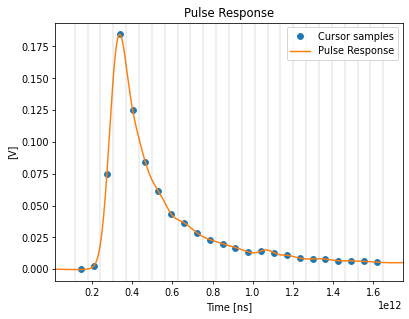

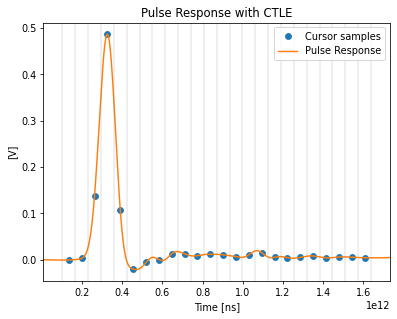

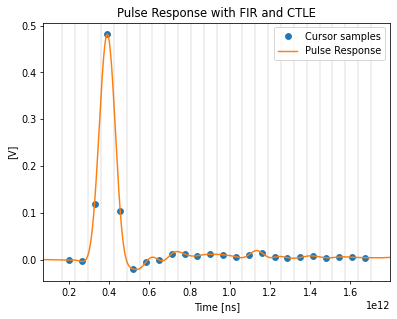

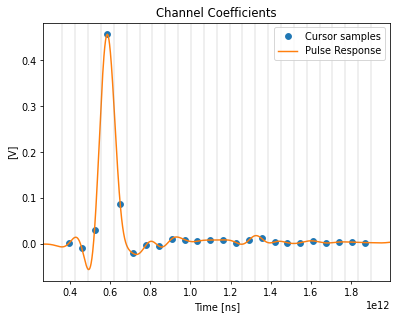

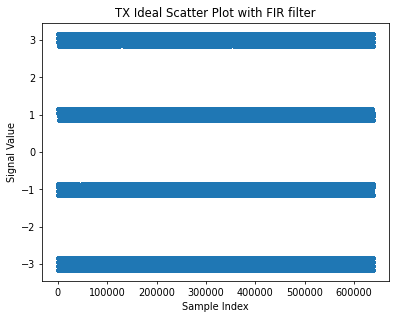

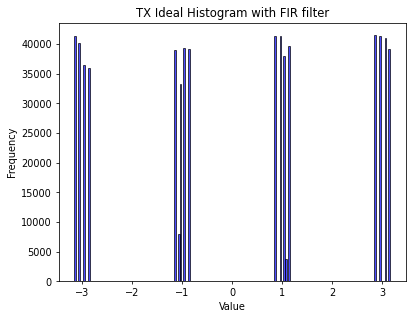

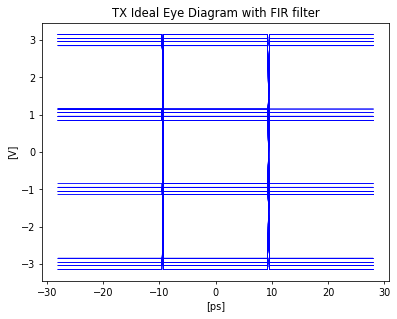

TX Ideal Eye Diagram with FIR filter Height: 6.1
TX Ideal Eye Diagram with FIR filter Width: 4.568868207745421
TX Ideal Eye Diagram with FIR filter Width: 0.6595365418894831


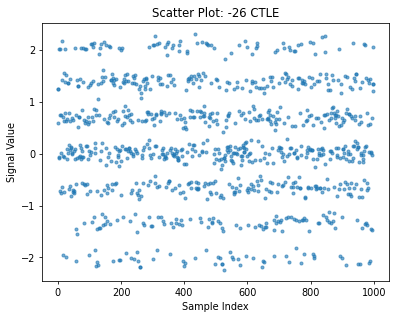

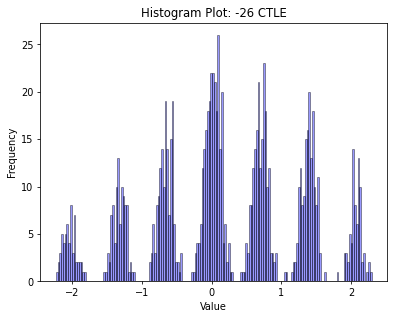

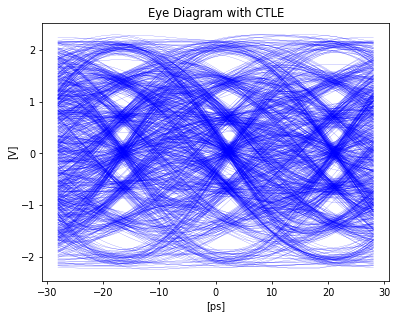

Eye Diagram with CTLE Height: 1.9941320282194988
Eye Diagram with CTLE Width: 2.1359350997046116
Eye Diagram with CTLE Width: 0.7802172781680979


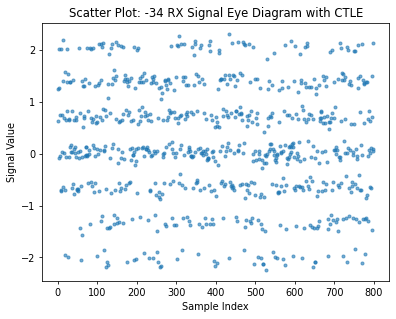

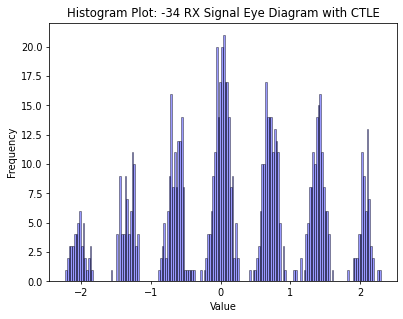

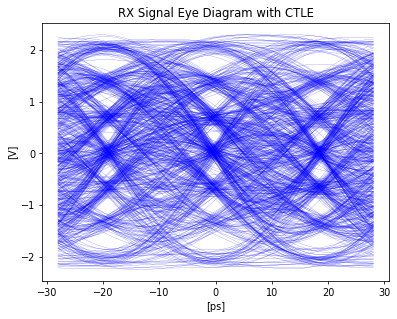

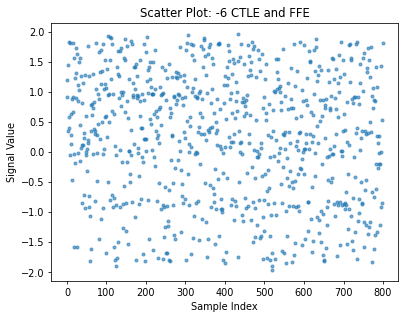

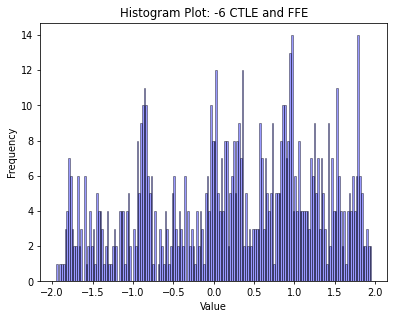

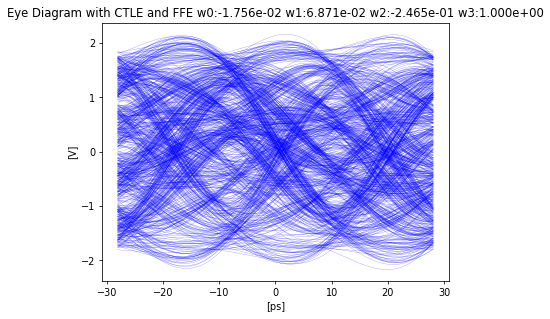

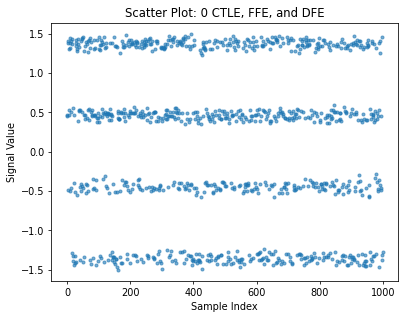

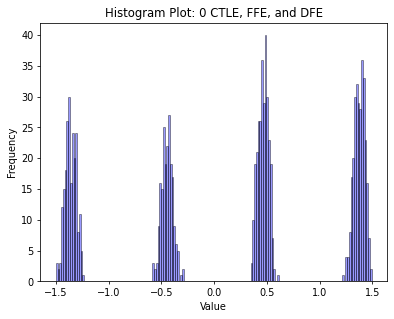

Slc THR:[np.float64(-93.5), np.float64(-38.0), np.float64(16.5)] LEVEL:[np.int64(-122), np.int64(-65), np.int64(-11), np.int64(44)]
Soft Slc SLC-ERR:[11.45553362 11.46094369 12.40174188 10.50774416 12.37789698 11.47176001
 12.30438168 11.52648917 10.50302439 12.38340648 12.44343521 12.3214116
 12.40116754 10.53831087 11.49969224 12.42931156 12.36780154  9.7140051
  9.60413695  9.67934065 11.55944333  9.56241361 10.59907597 11.46483201
  9.67400868 10.48243624  9.58869946 12.41657162 12.3490538  12.38095385
  9.59346775 12.30506192 12.27442514 10.45273065 12.37478229 11.39182398
 12.43078819 11.52852429 12.33297571 11.51216837 10.55260262  9.61812648
 11.53282486 10.4968757  12.40721252 10.58483752 12.44054553 11.50857491
 12.42679217 10.56391165  9.59143079 10.53884546 12.45554934 12.28063398
 11.47061568  9.65953552 11.46133977 11.41002206 12.33941397 10.59165609
 10.48033235 12.38826442 10.5756481  11.43007214 12.36940947 10.49951943
 12.40365306 12.27050849 11.53393394 12.42302031 1

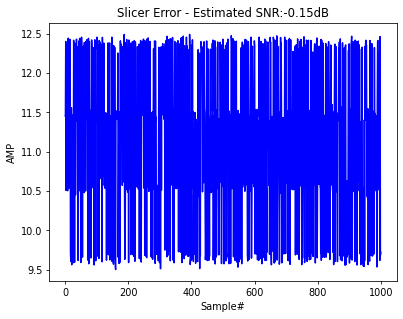

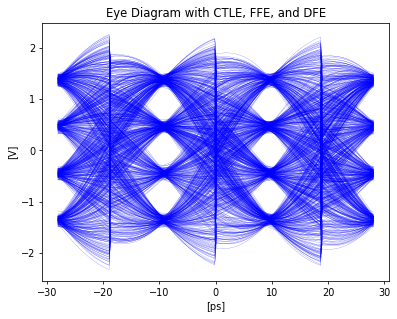

Eye Diagram with CTLE, FFE, and DFE Height: 3.3149596230761387
Eye Diagram with CTLE, FFE, and DFE Width: 2.1840072322341797
Eye Diagram with CTLE, FFE, and DFE Width: 0.6085920806623931


In [32]:
#import useful packages
import sys
import os
sys.path.append(os.getcwd())

import numpy as np
import scipy as sp

#load in data, and set up paramaters
h = np.load("./examples/example_channel/data/h_thru.npy")
h_ctle = np.load("./examples/example_channel/data/h_ctle.npy")
samples_per_symbol = 64
nyquist_f = 26.56e9

#pulse response of channel is convolution of impulse response and 1 UI of ones
pulse_response = sp.signal.fftconvolve(h, np.ones(samples_per_symbol), mode = "full")

#plot channel coefficients for pulse response
Signal.channel_coefficients(pulse_response, np.linspace(1,pulse_response.size,pulse_response.size), samples_per_symbol, 3, 20, title = "Pulse Response")

#pulse response with CTLE
pulse_response_ctle = sp.signal.fftconvolve(pulse_response, h_ctle, mode = "full")

#plot channel coefficients. observer lower post-cursor ISI
Signal.channel_coefficients(pulse_response_ctle, np.linspace(1,pulse_response_ctle.size,pulse_response_ctle.size), samples_per_symbol, 3, 20, title = "Pulse Response with CTLE")

#%% pick 1 tap TX FIR FILTER 

#arbitrarily take -0.05 tap weight to reduce precursor ISI
tx_fir_tap_weights = np.array([-0.05, 1])

#oversample
pulse_response_fir = sp.signal.fftconvolve(h, np.repeat(tx_fir_tap_weights,samples_per_symbol), mode = "full")

#convolution with pulse response
pulse_response_fir_ctle = sp.signal.fftconvolve(pulse_response_fir, h_ctle, mode = "full")

#plot channel coefficients
channel_coefficients = Signal.channel_coefficients(pulse_response_fir_ctle, np.linspace(1,pulse_response_fir_ctle.size,pulse_response_fir_ctle.size), samples_per_symbol, 3, 20, title = "Pulse Response with FIR and CTLE")[:4]


#%% Pick 3 precursor tap FFE

n_taps_pre = 3

#calculate RX FFE coeffiecients to force precursor ISI to 0
ffe_tap_weights = Signal.forcing_ffe(n_taps_pre, channel_coefficients)

#oversample ffe tap weights so we can perform convolution on 64X oversampled sign
rx_ffe_conv = np.zeros(64*ffe_tap_weights.size)

for i in range(ffe_tap_weights.size):
    rx_ffe_conv[i*64] = ffe_tap_weights[i]

#apply FFE to pulse response
pulse_response_fir_ctle_ffe = sp.signal.fftconvolve(pulse_response_fir_ctle, rx_ffe_conv, mode = "full")

#plot channel coefficients. observe lower pre-cursor ISI
channel_coefficients = Signal.channel_coefficients(pulse_response_fir_ctle_ffe, np.linspace(1,pulse_response_fir_ctle_ffe.size,pulse_response_fir_ctle_ffe.size), samples_per_symbol, 3, 20)

#amplitude of main cursor
main_cursor = channel_coefficients[3]

#zero-forcing DFE weights
dfe_tap_weights = channel_coefficients[4:]

#%% do time-domain simulation and plot eye diagrams

voltage_levels = np.array([-3,-1,1,3])

data = Prs.prqs10(1)

TX = Transmitter(data[:10000], voltage_levels, nyquist_f)

#apply FIR filter to transmitter waveform
TX.FIR(tx_fir_tap_weights)

#oversample data to 64 samples/symbols
TX.oversample(samples_per_symbol)

# Generate x-values based on the index of the signal data
x_values = np.arange(len(TX.signal_ideal[64*3:]))
# Create scatter plot
plt.figure(dpi=70)
plt.scatter(x_values, TX.signal_ideal[64*3:], s=scatter_s, alpha=scatter_alpha)  # Adjust size (`s`) and transparency (`alpha`) if needed
plt.xlabel("Sample Index")
plt.ylabel("Signal Value")
plt.title("TX Ideal Scatter Plot with FIR filter")
plt.show()

# Plot the histogram
plt.figure(dpi=70)
plt.hist(TX.signal_ideal[64*3:], bins=180, color='blue', edgecolor='black', alpha=0.7)
# Add titles and labels
plt.title('TX Ideal Histogram with FIR filter')
plt.xlabel('Value')
plt.ylabel('Frequency')
# Show the plot
plt.show()

#eye diagram of transmitter waveform
EyeDiagram.simple_eye(TX.signal_ideal[64*3:], samples_per_symbol*3, 500, TX.UI/TX.samples_per_symbol, "TX Ideal Eye Diagram with FIR filter")
eye_height, eye_width = EyeDiagram.measure_eye(TX.signal_ideal[64*3:], samples_per_symbol*3, 1000)
print(f"TX Ideal Eye Diagram with FIR filter Height: {eye_height}")
print(f"TX Ideal Eye Diagram with FIR filter Width: {eye_width}")
eye_width = EyeDiagram.measure_eye_width(TX.signal_ideal[64*3:], samples_per_symbol*3)
print(f"TX Ideal Eye Diagram with FIR filter Width: {eye_width}")

#signal at output of channel
signal_out = sp.signal.fftconvolve(TX.signal_ideal, h, mode = "same")[:64*500*12]

#signal at output of CTLE
signal_out_ctle = sp.signal.fftconvolve(signal_out, h_ctle, mode = "same")

for i in range(-26,-25,1):
    EyeDiagram.histogram(signal_out_ctle, samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, (samples_per_symbol+i), f"{i} CTLE")

#plot eye diagram
EyeDiagram.simple_eye(signal_out_ctle, samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, "Eye Diagram with CTLE")
eye_height, eye_width = EyeDiagram.measure_eye(signal_out_ctle, samples_per_symbol*3, 1000)
print(f"Eye Diagram with CTLE Height: {eye_height}")
print(f"Eye Diagram with CTLE Width: {eye_width}")
eye_width = EyeDiagram.measure_eye_width(signal_out_ctle, samples_per_symbol*3)
print(f"Eye Diagram with CTLE Width: {eye_width}")

#%%
RX = Receiver(signal_out_ctle, samples_per_symbol, nyquist_f, voltage_levels, shift = True, main_cursor = main_cursor)

for i in range(-34,-33,1):
    EyeDiagram.histogram(RX.signal, samples_per_symbol*3, 800, TX.UI/TX.samples_per_symbol, (samples_per_symbol+i), f"{i} RX Signal Eye Diagram with CTLE")

EyeDiagram.simple_eye(RX.signal, samples_per_symbol*3, 800, TX.UI/TX.samples_per_symbol, "RX Signal Eye Diagram with CTLE")

'''
ffe_tap_weights_0 = ffe_tap_weights[0]
ffe_tap_weights_1 = ffe_tap_weights[1]
ffe_tap_weights_2 = ffe_tap_weights[2]
ffe_tap_weights_3 = ffe_tap_weights[3]
step = 0.01
num_steps = 3
bound = step*num_steps
for weights_0 in np.arange(ffe_tap_weights_0 - bound, ffe_tap_weights_0 + bound, step):
    ffe_tap_weights[0] = weights_0
    for weights_1 in np.arange(ffe_tap_weights_1 - bound, ffe_tap_weights_1 + bound, step):
        ffe_tap_weights[1] = weights_1
        for weights_2 in np.arange(ffe_tap_weights_2 - bound, ffe_tap_weights_2 + bound, step):
            ffe_tap_weights[2] = weights_2
            for weights_3 in np.arange(ffe_tap_weights_3 - bound, ffe_tap_weights_3 + bound, step):
                ffe_tap_weights[3] = weights_3
'''
#signal after FFE
RX.FFE(ffe_tap_weights, n_taps_pre)

'''
# Generate x-values based on the index of the signal data
x_values = np.arange(len(RX.signal))
# Create scatter plot
plt.scatter(x_values, RX.signal, s=scatter_s, alpha=scatter_alpha)  # Adjust size (`s`) and transparency (`alpha`) if needed
plt.xlabel("Sample Index")
plt.ylabel("Signal Value")
plt.title("Scatter Plot of signal with CTLE and FFE")
plt.show()

# Plot the histogram
plt.figure(dpi=70)
plt.hist(RX.signal, bins=180, color='blue', edgecolor='black', alpha=0.7)
# Add titles and labels
plt.title('Histogram of signal with CTLE and FFE')
plt.xlabel('Value')
plt.ylabel('Frequency')
# Show the plot
plt.show()
'''

for i in range(-6,-5,1):
    EyeDiagram.histogram(RX.signal, samples_per_symbol*3, 800, TX.UI/TX.samples_per_symbol, (samples_per_symbol+i), f"{i} CTLE and FFE")

EyeDiagram.simple_eye(RX.signal, samples_per_symbol*3, 800, TX.UI/TX.samples_per_symbol, f"Eye Diagram with CTLE and FFE w0:{ffe_tap_weights[0]:.3e} w1:{ffe_tap_weights[1]:.3e} w2:{ffe_tap_weights[2]:.3e} w3:{ffe_tap_weights[3]:.3e}")

#RX.reset()

#signal after DFE
RX.pam4_DFE(dfe_tap_weights)

for i in range(0,1,1):
    capture_samples = EyeDiagram.histogram(RX.signal[64*300:], samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, (samples_per_symbol+i), f"{i} CTLE, FFE, and DFE")

estimate_slicers(np.array(capture_samples))

#plot eye diagram
EyeDiagram.simple_eye(RX.signal[64*300:], samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, f"Eye Diagram with CTLE, FFE, and DFE")
eye_height, eye_width = EyeDiagram.measure_eye(RX.signal[64*300:], samples_per_symbol*3, 1000)
print(f"Eye Diagram with CTLE, FFE, and DFE Height: {eye_height}")
print(f"Eye Diagram with CTLE, FFE, and DFE Width: {eye_width}")
eye_width = EyeDiagram.measure_eye_width(RX.signal[64*300:], samples_per_symbol*3)
print(f"Eye Diagram with CTLE, FFE, and DFE Width: {eye_width}")


#%%save the tap weights chosen
np.save("./examples/example_channel/data/rx_ffe_tap_weights.npy",ffe_tap_weights)
np.save("./examples/example_channel/data/rx_dfe_tap_weights.npy",dfe_tap_weights)
np.save("./examples/example_channel/data/tx_fir_tap_weights.npy",tx_fir_tap_weights)


## Generate a channel model
Generate a channel model for a 50 Ohm coaxial cable of lengths 10cm and 15cm having skin effect constant 87 and dielectric loss coefficient 0.01. Plot the frequency response magnitude
from DC to 100Ghz, as well as the impulse and pulse response assuming perfect 50 Ohm matching for source and termination impedance. Now introduce 200fF shunt capacitance at
each end of the cable and compare the resulting frequency responses. In each case, plot an eye diagram of a 4-PAM waveform through the channel at 100Gbps.

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_9040\2571704575.py:67: RuntimeWarning: invalid value encountered in power
  C= C0 * (1j*w/w_0)**(-2*theta_0/np.pi)


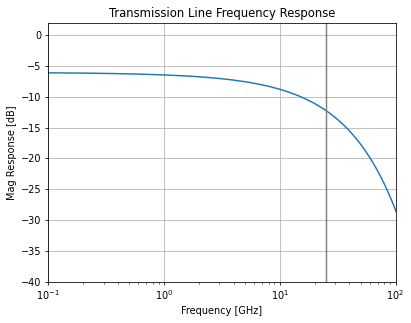

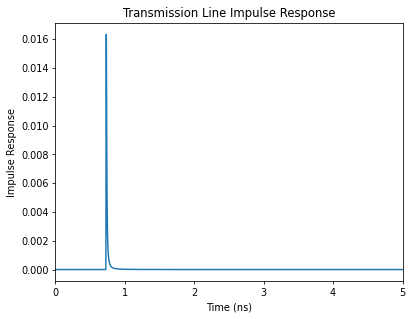

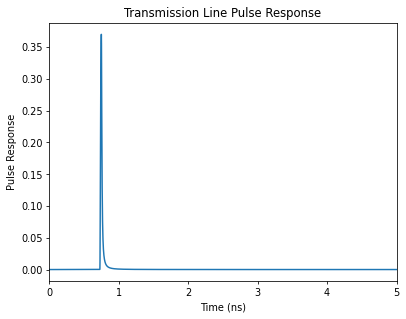

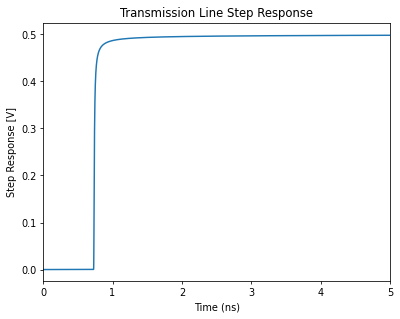

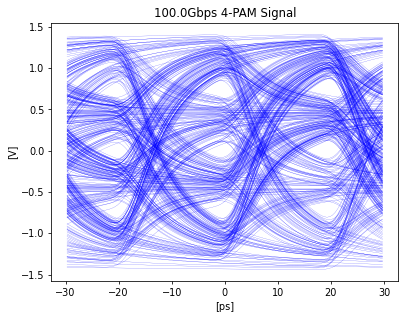

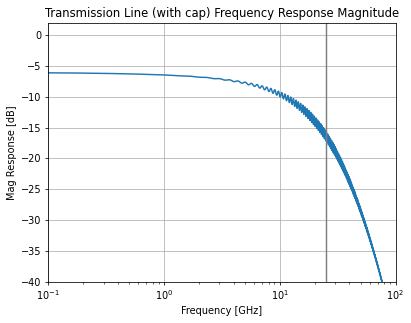

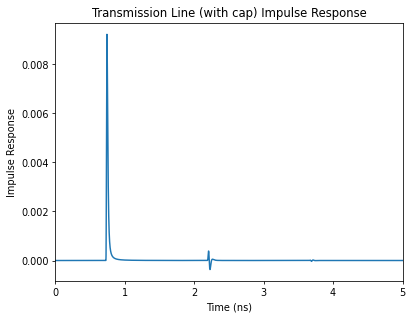

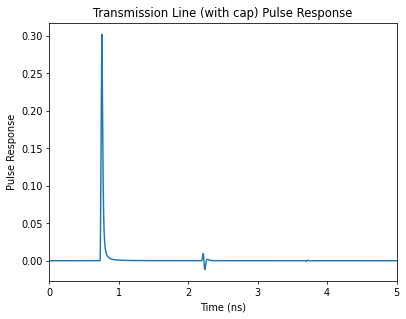

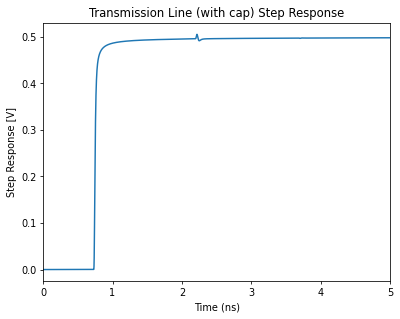

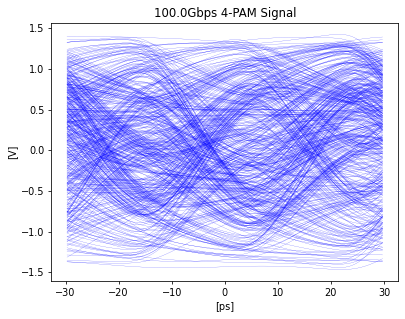

In [33]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

#% electrical loss parameters

#All AC parameters are specified at this frequency
w_0 = 2*np.pi*10e9

#loss tangent = theta_0/(2*pi)
#theta_0 = 0.022
theta_0 = 0.01

#skin-effect scaling factor [ohms/m @ w_0]
k_r = 87

#dc resistance [ohm/m]
RDC = 0.0001

# Biuld frequency vector

#fmax=1e12 -> time step = 500fs
fmax=1e12

#frequency vector (Hz)
k = 14
f = np.linspace(0,fmax,2**k+1)

#frequency vector (rad/s)
w = f*2*np.pi

# Constants

#speed of light [m/s]
c = 2.998e8

#Vacuum permittivity [F/m]
eps_0 = 8.85*1e-12

# Transmission line parameters

#Effective relative dielectric constant
eps_r = 4.9

#Propagation velocity of the transmission line [m/s]
v0 = np.sqrt(1/eps_r)*c

#Characteristic impedance [ohm]
Z0 = 50

#Inductance [H/m]
L0 = Z0/v0

#Capacitance [F/m]
C0 = 1/(Z0*v0)

#Conductance [S/m]
G0 = 1e-12

#Resistance
RAC = (k_r*(1+1j)*np.sqrt(w/w_0))

#%% Generate frequency-dependent RLGC for the lossy transmission line
R=np.sqrt(RDC**2 + RAC**2)
L=L0*np.ones(np.size(f))
G=G0*np.ones(np.size(f))
C= C0 * (1j*w/w_0)**(-2*theta_0/np.pi)

if (f[0]==0):
   C[0] = C[1]
   
# transmission line length [m]
d = 0.1

#create transmission ABCD paramaters
tline = ChModel.rlgc(R,L,G,C,d,f)

#%% source impedance
r_source = 50
source = ChModel.impedance(r_source*np.ones(np.size(f)))

#termination admittance
r_term = 50
termination = ChModel.admittance(np.ones(np.size(f))/r_term)

#channel is the series connection of the source, transmission line, and termination
channel = ChModel.series(np.array([source,tline,termination]))

#%%
# frequency domain response
Hchannel = 1/channel[:,0,0]

#Hchannel = Hchannel/abs(Hchannel[0])

np.save("./examples/example_channel/data/Hchannel",Hchannel)

# impulse response
h,t = ChModel.freq2impulse(Hchannel,f)
np.save("./examples/example_channel/data/h.npy",h)
np.save("./examples/example_channel/data/t.npy",t)

#step response
hstep = sp.signal.convolve(h,np.ones(np.shape(h)))[:np.size(h)]

#100Gbps
data_rate = 100e9

#Pam-4 Signalling
t_symbol = 2/data_rate

#time step between samples of impulse response
t_sample = 1/(2*fmax)

#number of time samples in one PAM-4 symbol
samples_per_symbol = int(t_symbol/t_sample)

#response of transmission line to one UI pulse
hpulse = sp.signal.convolve(h,np.ones(np.array([samples_per_symbol,])))[:np.size(h)]
np.save("./examples/example_channel/data/hpulse.npy",hpulse)

#%% Plots

plt.figure(dpi=70)
plt.title('Transmission Line Frequency Response')
plt.semilogx(1e-9*f,20*np.log10(np.abs(Hchannel)))
plt.xlim([0.1, 100])
plt.ylim([-40, 2])
plt.xlabel('Frequency [GHz]')
plt.ylabel('Mag Response [dB]')
plt.grid()
#nyquist f for 100G 4-PAM is 25G
plt.axvline(x=25,color = 'grey', label = "Nyquist Frequency")
plt.show()

plt.figure(dpi=70)
plt.plot((t*1e9),h)
plt.title('Transmission Line Impulse Response')
plt.ylabel('Impulse Response')
plt.xlabel('Time (ns)')
plt.xlim([0, 5])
#plt.ylim([-0.01, 0.08])
plt.show()

plt.figure(dpi=70)
plt.plot((t*1e9),hpulse)
plt.title('Transmission Line Pulse Response')
plt.ylabel('Pulse Response')
plt.xlabel('Time (ns)')
plt.xlim([0, 5])
#plt.ylim([-0.01, 0.08])
plt.show()

plt.figure(dpi=70)
plt.plot(t*1e9,hstep)
plt.title('Transmission Line Step Response')
plt.ylabel('Step Response [V]')
plt.xlabel('Time (ns)')
plt.xlim([0, 5])
plt.show()


#%% Eye Diagram

#generate binary data
data = Prs.prqs10(1)[:10000]

data_rate = 100e9

#generate Baud-Rate sampled signal from data
signal_BR = Signal.pam4_input_BR(data)

#oversampled signal
signal_ideal = np.repeat(signal_BR, samples_per_symbol)

#eye diagram of ideal signal

signal_out = sp.signal.convolve(h,signal_ideal)
                                
EyeDiagram.simple_eye(signal_out[100*samples_per_symbol:], samples_per_symbol*3, 500, t_sample, "{}Gbps 4-PAM Signal".format(data_rate/1e9))

#%% Add parallel shunt capacitance to source and termination

#200 fF capacitance
C = 200*1e-15

#ABCD paramaters of shunt cap network
cap_network = ChModel.shunt_cap(C,w*1j)

#channel is the series connection of the networks
channel = ChModel.series(np.array([source,cap_network,tline,cap_network,termination]))

#%%
# frequency domain response
Hchannel = 1/channel[:,0,0]

#Hchannel = Hchannel/abs(Hchannel[0])

np.save("./examples/example_channel/data/Hchannel_cap",Hchannel)

# impulse response
h,t = ChModel.freq2impulse(Hchannel,f)

#step response
hstep = sp.signal.convolve(h,np.ones(np.shape(h)))[:np.size(h)]

#100Gbps
data_rate = 100e9

#Pam-4 Signalling
t_symbol = 2/data_rate

#time step between samples of impulse response
t_sample = 1/(2*fmax)

#number of time samples in one PAM-4 symbol
samples_per_symbol = int(t_symbol/t_sample)

#response of transmission line to one UI pulse
hpulse = sp.signal.convolve(h,np.ones(np.array([samples_per_symbol,])))[:np.size(h)]
np.save("./examples/example_channel/data/hpulse_cap.npy",hpulse)

#%% Plots

plt.figure(dpi=70)
plt.title('Transmission Line (with cap) Frequency Response Magnitude')
plt.semilogx(1e-9*f,20*np.log10(np.abs(Hchannel)))
plt.xlim([0.1, 100])
plt.ylim([-40, 2])
plt.xlabel('Frequency [GHz]')
plt.ylabel('Mag Response [dB]')
plt.grid()
#nyquist f for 100G 4-PAM is 25G
plt.axvline(x=25,color = 'grey', label = "Nyquist Frequency")
plt.show()


plt.figure(dpi=70)
plt.plot((t*1e9),h)
plt.title('Transmission Line (with cap) Impulse Response')
plt.ylabel('Impulse Response')
plt.xlabel('Time (ns)')
plt.xlim([0, 5])
#plt.ylim([-0.01, 0.08])
plt.show()

plt.figure(dpi=70)
plt.plot((t*1e9),hpulse)
plt.title('Transmission Line (with cap) Pulse Response')
plt.ylabel('Pulse Response')
plt.xlabel('Time (ns)')
plt.xlim([0, 5])
#plt.ylim([-0.01, 0.08])
plt.show()

plt.figure(dpi=70)
plt.plot(t*1e9,hstep)
plt.title('Transmission Line (with cap) Step Response')
plt.ylabel('Step Response [V]')
plt.xlabel('Time (ns)')
plt.xlim([0, 5])
plt.show()


#%% Eye Diagram
#eye diagram of ideal signal

signal_out_cap = sp.signal.convolve(h,signal_ideal)
                                
EyeDiagram.simple_eye(signal_out_cap[100*samples_per_symbol:], samples_per_symbol*3, 500, t_sample, "{}Gbps 4-PAM Signal".format(data_rate/1e9))

#%% save data for next homework assignment
np.save("./examples/example_channel/data/signal.npy",signal_out)
np.save("./examples/example_channel/data/signal_cap.npy",signal_out_cap)
np.save("./examples/example_channel/data/f.npy",f)
np.save("./examples/example_channel/data/w.npy",w)

## LMS FFE and DFE
Filter the channel outputs with a linear CTLE modelled with a zero at 𝜔z = 5 × 10(10) 𝑟𝑎𝑑/𝑠, two poles at 𝜔p = 1.7 × 10(11) 𝑟𝑎𝑑/𝑠 and a DC gain of 1.
Using the information from lecture 4 slide 6 on active CTLE design, suggest component values for a typical CTLE circuit that would have such poles and zeros. Assume the bias current is set so
that input transistors have gm = 25 millisiemens. Find the MMSE coefficients of a digital FFE with 2 pre-taps and 5 post-taps, and DFE with 2-taps to finish equalizing the CTLE output. Plot and
compare eye diagrams of the signal before CTLE, after CTLE, after FFE, and after DFE.

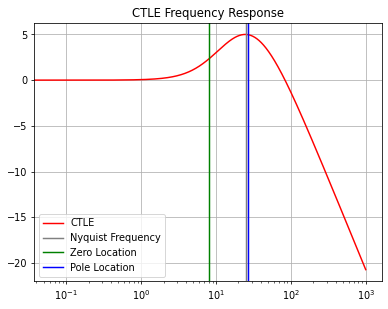

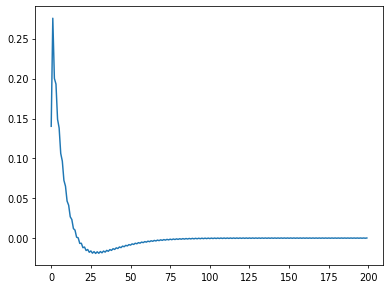

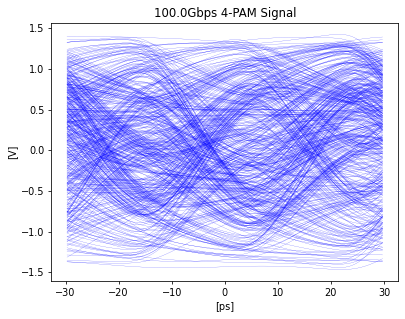

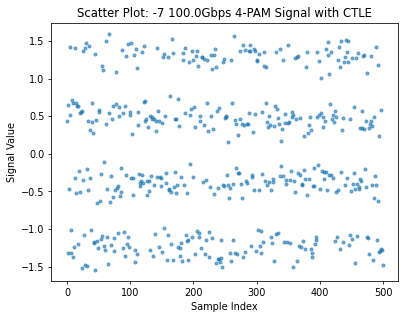

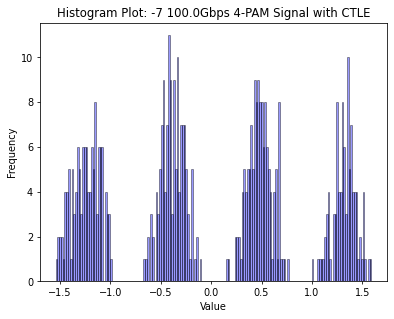

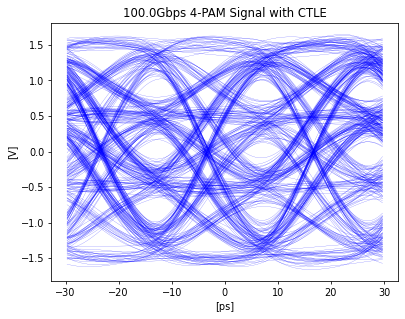

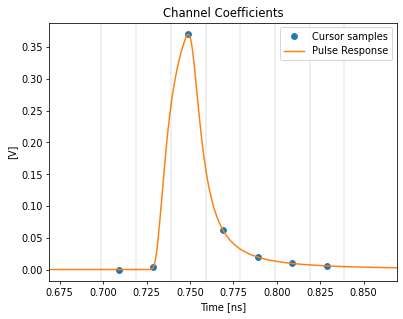

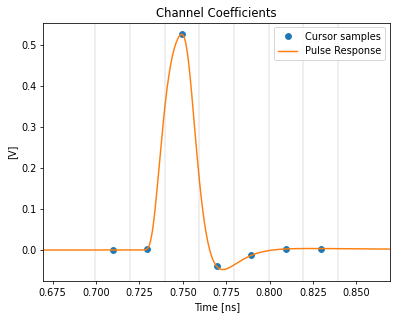

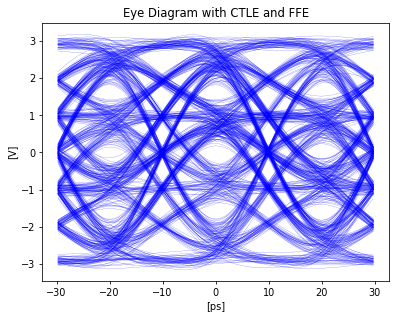

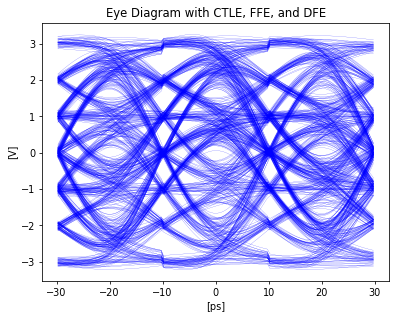

True

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf
import scipy as sp

f = np.load("./examples/example_channel/data/f.npy")
w = np.load("./examples/example_channel/data/w.npy")

h_pulse = np.load("./examples/example_channel/data/hpulse.npy")
t = np.load("./examples/example_channel/data/t.npy")

signal = np.load("./examples/example_channel/data/signal.npy")
signal = np.load("./examples/example_channel/data/signal_cap.npy")

#Hchannel = np.load("./data/Hchannel.npy")

samples_per_symbol = 40
data_rate = 100e9

#set poles and zeroes for peaking at nyquist freq
#high peaking because channel is high insertion loss
z = 5e10
p = 1.7e11
k = p**2/z

#calculate Frequency response of CTLE at given frequencies
w, H_ctle = sp.signal.freqs([k/p**2, k*z/p**2], [1/p**2, 2/p, 1], w)

#bode plot of CTLE transfer function
plt.figure(dpi=70)
plt.semilogx(1e-9*f,20*np.log10(abs(H_ctle)), color = "red", label = 'CTLE')
plt.title("CTLE Frequency Response")
plt.grid()
plt.axvline(x=25,color = 'grey', label = "Nyquist Frequency")
plt.axvline(x=z/(2*np.pi)*1e-9,color = 'green', label = "Zero Location")
plt.axvline(x=p/(2*np.pi)*1e-9,color = 'blue', label = "Pole Location")
plt.legend()

#%%
h_ctle, t_ctle = ChModel.freq2impulse(H_ctle,f)
h_ctle = h_ctle[0:200]
plt.figure(dpi=70)
plt.plot(h_ctle)

#%% Eye diagram of signal with and without CTLE

EyeDiagram.simple_eye(signal[100*samples_per_symbol:], samples_per_symbol*3, 500, 500*1e-15, "{}Gbps 4-PAM Signal".format(data_rate/1e9))

signal_ctle = sp.signal.convolve(signal,h_ctle)

for i in range(-7,-6,1):
    EyeDiagram.histogram(signal_ctle[100*samples_per_symbol:], samples_per_symbol*3, 500, 500*1e-15, (samples_per_symbol+i), f"{i} {data_rate/1e9}Gbps 4-PAM Signal with CTLE")

EyeDiagram.simple_eye(signal_ctle[100*samples_per_symbol:], samples_per_symbol*3, 500, 500*1e-15, "{}Gbps 4-PAM Signal with CTLE".format(data_rate/1e9))

#%%
h_pulse_ctle = sp.signal.convolve(h_pulse,h_ctle)

FFE_pre = 2
FFE_taps = 7
FFE_post = FFE_taps - FFE_pre - 1
DFE_taps = 2

Signal.channel_coefficients(h_pulse[:t.size],t,40,2,4)

h = Signal.channel_coefficients(h_pulse_ctle[:t.size],t,40,2,4)
#%%
#h /= h.max()
#print('h: ',h)

channel_main = h.argmax()

#main_cursor = h[channel_main]
main_cursor = 1

#generate binary data
data = Prs.prqs10(1)[:10000]

voltage_levels = np.array([-3, -1, 1, 3])

#generate Baud-Rate sampled signal from data
signal_BR = Signal.pam4_input_BR(data)

signal_rx = sp.signal.fftconvolve(h, signal_BR)[:len(signal_BR)]

signal_rx_cropped = signal_rx[channel_main:]

reference_signal = signal_BR[:1000]

w_ffe_init = np.zeros([7,])
w_dfe_init = np.zeros([2,])

w_ffe, w_dfe, v_combined_ffe, v_combined_dfe, z_combined, e_combined = \
Signal.lms_equalizer(signal_rx_cropped, 0.001, len(signal_rx_cropped), w_ffe_init, FFE_pre, w_dfe_init,  voltage_levels, reference=reference_signal[:1000])

#%%

#voltage_levels = np.array([-3,-1,1,3])

nyquist_f = 25e9

RX = Receiver(signal_ctle, samples_per_symbol, nyquist_f, voltage_levels,main_cursor=main_cursor)

#EyeDiagram.simple_eye(RX.signal, samples_per_symbol*3, 800, TX.UI/TX.samples_per_symbol, "Eye Diagram with CTLE")

RX.FFE(w_ffe, FFE_pre)

EyeDiagram.simple_eye(RX.signal[int(100.5*samples_per_symbol):], samples_per_symbol*3, 800, 500*1e-15, "Eye Diagram with CTLE and FFE")

RX.pam4_DFE(w_dfe)

EyeDiagram.simple_eye(RX.signal[int(100.5*samples_per_symbol):], samples_per_symbol*3, 800, 500*1e-15, "Eye Diagram with CTLE, FFE, and DFE")

## Simulation to test BER
This file shows example of simulation to test BER of link with equalization modelled in previous files

This file also includes gaussian jitter, and a bandwidth-limiting filter applied to the transmitter waveform
AWGN is added to the signal after the channel + CTLE

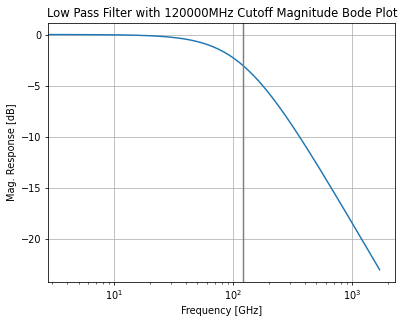

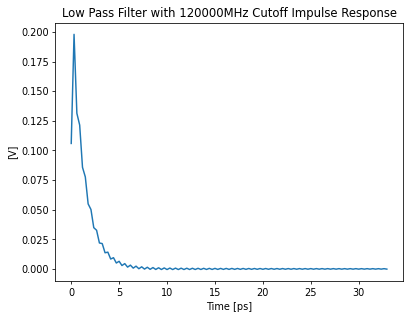

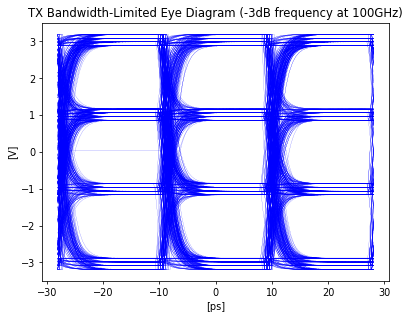

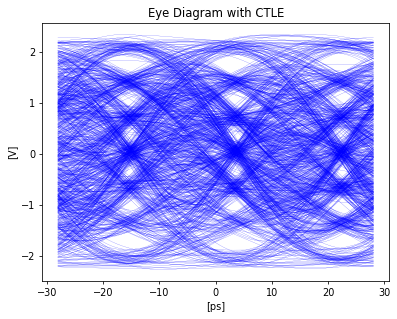

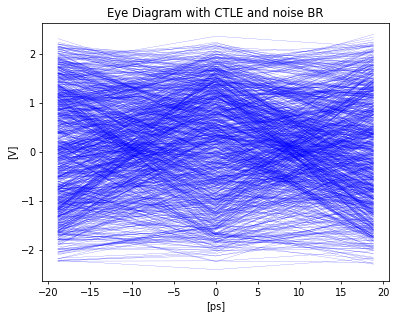

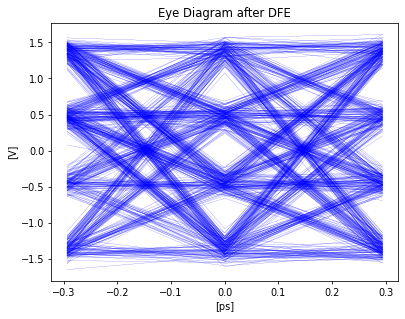

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_9040\4253831323.py:391: RuntimeWarning: overflow encountered in scalar subtract
  if (abs(data[i]-prqs[(start_idx+i)%(2**(n*2)-1)]) == 2):


Bits Transmitted = 2097112 Bit Errors = 125
Bit Error Ratio =  5.96057816654523e-05


In [35]:
import sys
import os
sys.path.append(os.getcwd())

import numpy as np
import scipy as sp

#load data from previous files
h = np.load("./examples/example_channel/data/h_thru.npy")
h_ctle = np.load("./examples/example_channel/data/h_ctle.npy")
ffe_tap_weights = np.load("./examples/example_channel/data/rx_ffe_tap_weights.npy")
dfe_tap_weights = np.load("./examples/example_channel/data/rx_dfe_tap_weights.npy")
tx_fir_tap_weights = np.load("./examples/example_channel/data/tx_fir_tap_weights.npy")

#set up paramaters
nyquist_f = 26.56e9
samples_per_symbol = 64
voltage_levels = np.array([-3,-1,1,3])

#pseudo-random data for simulation
data = Prs.prqs10(1)

#set up transmitter waveform
TX = Transmitter(data, voltage_levels, nyquist_f)

#apply FIR filter
TX.FIR(tx_fir_tap_weights)

#oversample transmitter waveform
TX.oversample(samples_per_symbol)

#add 0-mean jitter with standard deviation that is 2.5 % of UI time
TX.gaussian_jitter(stdev_div_UI=0.025)

#low-pass filter with cutoff frequency 120G
TX.tx_bandwidth(freq_bw=120e9)

#plot eye diagram of bandwidth-limitied transmitter waveform
EyeDiagram.simple_eye(TX.signal, samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, "TX Bandwidth-Limited Eye Diagram (-3dB frequency at 100GHz)")
#%% signal after channel
signal_out = sp.signal.fftconvolve(TX.signal, h, mode = "same")

#optional: add xtalk interference
#xtalk = np.load("./data/xt_response.npy")
#signal_out = signal_out[:xtalk.size]+xtalk

signal_out_ctle = sp.signal.fftconvolve(signal_out, h_ctle, mode = "same")
#%%plot eye diagram with ctle
EyeDiagram.simple_eye(signal_out_ctle, samples_per_symbol*3, 1000, TX.UI/TX.samples_per_symbol, "Eye Diagram with CTLE")

main_cursor = np.max(signal_out_ctle)/np.max(voltage_levels)

RX = Receiver(signal_out_ctle, samples_per_symbol, nyquist_f, voltage_levels, shift = True, main_cursor = 0.5)

#slice signal at centre of eye
RX.slice_signal()

#add noise with standard deviation 0.1
RX.signal_BR =  RX.signal_BR + np.random.normal(scale=0.05, size = RX.signal_BR.size)

#plot baud-rate eye diagram with ctle and noise
EyeDiagram.simple_eye(RX.signal_BR, 3, 1000, TX.UI, "Eye Diagram with CTLE and noise BR")

#apply feed-forward equalization to baud-rate-sampled signal
RX.FFE_BR(ffe_tap_weights, 3)

#EyeDiagram.simple_eye(RX.signal_BR, 3, 800, TX.UI/TX.samples_per_symbol, "Eye Diagram after FFE")

# apply decision-feedback equalization 
RX.pam4_DFE_BR(dfe_tap_weights)

#plot baud-rate eye diagram after DFE
EyeDiagram.simple_eye(RX.signal_BR, 3, 800, TX.UI/TX.samples_per_symbol, "Eye Diagram after DFE")

#%%check the number of errors and calculate BER
err = Prs.prqs_checker(10, data, RX.symbols_out[10:-10])

print("Bits Transmitted =", RX.symbols_out[10:-10].size*2, 'Bit Errors =', err[0])

print("Bit Error Ratio = ", err[0]/(RX.symbols_out[10:-10].size*2))

## Bit Error Ratio (BER)
This script is designed to model the Bit Error Ratio (BER) of a SerDes (Serializer/Deserializer) system.

In [36]:
#import useful packages
import sys
import os
sys.path.append(os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

def serdesBerModel(channel_f,
             channel_h,
             channel_H,
             samplesPerSymbol,
             ctle_zero,
             ctle_pole,
             txFirTapWeights,
             ffeTapsPre,
             ffe_n_precursors,
             ffe_n_postcursors,
             dfe_n_precursors,
             dfe_n_postcursors):

    #load in data generated by 1_channel.py
    f = channel_f
    h = channel_h
    H = channel_H

    if ctle_zero == 0 or ctle_pole == 0 or ctle_zero >= ctle_pole:
        return 0, 0, 1.0

    #frequency vector in rad/s
    w = f*(2*np.pi)

    #oversampling ratio used in 1_channel.py
    samples_per_symbol = samplesPerSymbol

    #set up paramaters
    nyquist_f = 26.56e9
    voltage_levels = np.array([-3,-1,1,3])

    #set poles and zeroes for peaking at nyquist freq
    #high peaking because channel is high insertion loss
    z = ctle_zero
    p = ctle_pole
    k = p**2/z

    #calculate Frequency response of CTLE at given frequencies
    w, H_ctle = sp.signal.freqs([k/p**2, k*z/p**2], [1/p**2, 2/p, 1], w)

    #compute and save impulse response of CTLE transfer function
    h_ctle, t_ctle = ChModel.freq2impulse(H_ctle,f)
    h_ctle = h_ctle[0:200]

    #pulse response of channel is convolution of impulse response and 1 UI of ones
    pulse_response = sp.signal.fftconvolve(h, np.ones(samples_per_symbol), mode = "full")

    # pick 1 tap TX FIR FILTER 

    #arbitrarily take -0.05 tap weight to reduce precursor ISI
    tx_fir_tap_weights = np.array([txFirTapWeights, 1])

    #oversample
    pulse_response_fir = sp.signal.fftconvolve(h, np.repeat(tx_fir_tap_weights,samples_per_symbol), mode = "full")

    #convolution with pulse response
    pulse_response_fir_ctle = sp.signal.fftconvolve(pulse_response_fir, h_ctle, mode = "full")

    #plot channel coefficients
    channel_coefficients = Signal.channel_coefficients(pulse_response_fir_ctle,
                                                       np.linspace(1,pulse_response_fir_ctle.size,pulse_response_fir_ctle.size),
                                                       samples_per_symbol,
                                                       ffe_n_precursors,
                                                       ffe_n_postcursors,
                                                       title = "Pulse Response with FIR and CTLE")[:4]

    #%% Pick 3 precursor tap FFE

    n_taps_pre = ffeTapsPre

    #calculate RX FFE coeffiecients to force precursor ISI to 0
    ffe_tap_weights = Signal.forcing_ffe(n_taps_pre, channel_coefficients)

    #oversample ffe tap weights so we can perform convolution on 64X oversampled sign
    rx_ffe_conv = np.zeros(64*ffe_tap_weights.size)

    for i in range(ffe_tap_weights.size):
        rx_ffe_conv[i*64] = ffe_tap_weights[i]

    #apply FFE to pulse response
    pulse_response_fir_ctle_ffe = sp.signal.fftconvolve(pulse_response_fir_ctle, rx_ffe_conv, mode = "full")

    #plot channel coefficients. observe lower pre-cursor ISI
    channel_coefficients = Signal.channel_coefficients(pulse_response_fir_ctle_ffe,
                                                       np.linspace(1,pulse_response_fir_ctle_ffe.size,pulse_response_fir_ctle_ffe.size),
                                                       samples_per_symbol,
                                                       dfe_n_precursors,
                                                       dfe_n_postcursors)

    #amplitude of main cursor
    main_cursor = channel_coefficients[3]

    #zero-forcing DFE weights
    dfe_tap_weights = channel_coefficients[4:]

    #pseudo-random data for simulation
    data = Prs.prqs10(1)

    #set up transmitter waveform
    TX = Transmitter(data, voltage_levels, nyquist_f)

    #apply FIR filter
    TX.FIR(tx_fir_tap_weights)

    #oversample transmitter waveform
    TX.oversample(samples_per_symbol)

    #add 0-mean jitter with standard deviation that is 2.5 % of UI time
    TX.gaussian_jitter(stdev_div_UI=0.025)

    #low-pass filter with cutoff frequency 120G
    TX.tx_bandwidth(freq_bw=120e9)

    # signal after channel
    signal_out = sp.signal.fftconvolve(TX.signal, h, mode = "same")

    #optional: add xtalk interference
    #xtalk = np.load("./data/xt_response.npy")
    #signal_out = signal_out[:xtalk.size]+xtalk

    signal_out_ctle = sp.signal.fftconvolve(signal_out, h_ctle, mode = "same")

    main_cursor = np.max(signal_out_ctle)/np.max(voltage_levels)

    RX = Receiver(signal_out_ctle, samples_per_symbol, nyquist_f, voltage_levels, shift = True, main_cursor = 0.5)

    #slice signal at centre of eye
    RX.slice_signal()

    #add noise with standard deviation 0.1
    RX.signal_BR =  RX.signal_BR + np.random.normal(scale=0.05, size = RX.signal_BR.size)

    #apply feed-forward equalization to baud-rate-sampled signal
    RX.FFE_BR(ffe_tap_weights, 3)

    # apply decision-feedback equalization 
    RX.pam4_DFE_BR(dfe_tap_weights)

    #%%check the number of errors and calculate BER
    err = Prs.prqs_checker(10, data, RX.symbols_out[10:-10])
    bits_transmitted = RX.symbols_out[10:-10].size*2
    bit_error = err[0]
    bit_error_ratio = err[0]/(RX.symbols_out[10:-10].size*2)
    return bits_transmitted, bit_error, bit_error_ratio

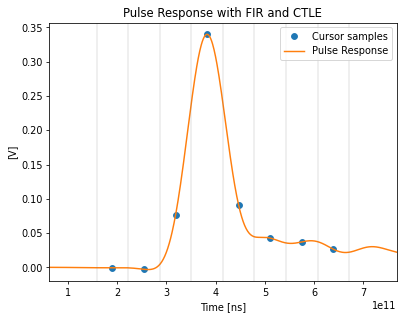

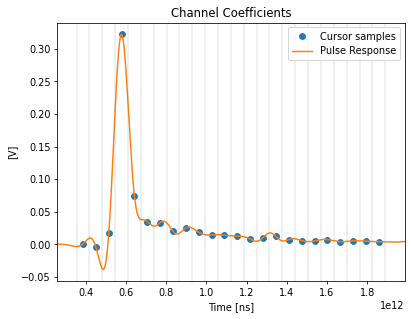

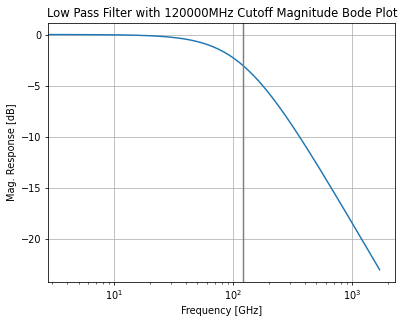

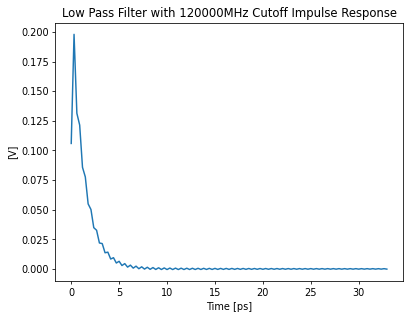

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_9040\4253831323.py:391: RuntimeWarning: overflow encountered in scalar subtract
  if (abs(data[i]-prqs[(start_idx+i)%(2**(n*2)-1)]) == 2):


In [ ]:
#load in data generated by 1_channel.py
channel_f = np.load("./examples/example_channel/data/f.npy")
channel_h = np.load("./examples/example_channel/data/h_thru.npy")
channel_H = np.load("./examples/example_channel/data/TF_thru.npy")

samplesPerSymbol = 64

ctle_zero = 2e10
ctle_pole = 1.7e11

#arbitrarily take -0.05 tap weight to reduce precursor ISI
txFirTapWeights = -0.05

# Pick 3 precursor tap FFE
ffeTapsPre = 3

ffe_n_precursors = 3
ffe_n_postcursors = 4

dfe_n_precursors = 3
dfe_n_postcursors = 20

bits_transmitted, bit_error, bit_error_ratio = serdesBerModel(channel_f,
                                                            channel_h,
                                                            channel_H,
                                                            samplesPerSymbol,
                                                            ctle_zero,
                                                            ctle_pole,
                                                            txFirTapWeights,
                                                            ffeTapsPre,
                                                            ffe_n_precursors,
                                                            ffe_n_postcursors,
                                                            dfe_n_precursors,
                                                            dfe_n_postcursors)

print("Bits Transmitted =", bits_transmitted, 'Bit Errors =', bit_error)
print("Bit Error Ratio = ", bit_error_ratio)